In [1]:
import numpy as np

def load_rowland_sessions(npz_path):
    """Load sessions from the exported .npz file."""
    data = np.load(npz_path, allow_pickle=True)
    session_ids = data['session_ids']
    
    sessions = {}
    for sid in session_ids:
        prefix = f"session_{sid}_"
        sessions[sid] = {
            'signature': str(data[f'{prefix}signature']),
            'mouse': str(data[f'{prefix}mouse']),
            'run_number': int(data[f'{prefix}run_number']),
            'name': str(data[f'{prefix}name']),
            'filter_ps_time': data[f'{prefix}filter_ps_time'],
            'behaviour_trials': data[f'{prefix}behaviour_trials'],
            'is_target': data[f'{prefix}is_target'],
            'trial_subsets': data[f'{prefix}trial_subsets'],
            'n_cells': int(data[f'{prefix}n_cells']),
            'n_trials': int(data[f'{prefix}n_trials']),
            'n_times': int(data[f'{prefix}n_times']),
            's1_bool': data[f'{prefix}s1_bool'],
            's2_bool': data[f'{prefix}s2_bool'],
            'outcome': data[f'{prefix}outcome'],
            'frequency': float(data[f'{prefix}frequency']),
        }
    return sessions

In [2]:
sessions=load_rowland_sessions('/home/patriciobarber/AdaptiveLatents/workspace/datasets/rowland23/all_sessions.npz')

In [3]:
s0 = sessions[0]

print("=== Session 0 Overview ===")
print(f"Signature: {s0['signature']}")
print(f"Mouse: {s0['mouse']}")
print(f"Name: {s0['name']}")
print(f"Frequency: {s0['frequency']} Hz")

print(f"\n=== Neural Data ===")
print(f"Number of cells: {s0['n_cells']}")
print(f"  - S1 cells: {s0['s1_bool'].sum()}")
print(f"  - S2 cells: {s0['s2_bool'].sum()}")
print(f"Number of trials: {s0['n_trials']}")
print(f"Number of timepoints: {s0['n_times']}")
print(f"behaviour_trials shape: {s0['behaviour_trials'].shape}")

print(f"\n=== Time Info ===")
print(f"Time array: {s0['filter_ps_time'][0]:.2f}s to {s0['filter_ps_time'][-1]:.2f}s")

print(f"\n=== Stimulation ===")
print(f"is_target shape: {s0['is_target'].shape}")
print(f"Unique stim conditions: {np.unique(s0['trial_subsets'])} cells")
for n_stim in np.unique(s0['trial_subsets']):
    print(f"  - {n_stim} cells stimulated: {np.sum(s0['trial_subsets'] == n_stim)} trials")

print(f"\n=== Behavioral Outcomes ===")
for outcome in np.unique(s0['outcome']):
    print(f"  - {outcome}: {np.sum(s0['outcome'] == outcome)} trials")

=== Session 0 Overview ===
Signature: J064_R10
Mouse: J064
Name: Mouse J064, run 10
Frequency: 30.0 Hz

=== Neural Data ===
Number of cells: 471
  - S1 cells: 319
  - S2 cells: 152
Number of trials: 162
Number of timepoints: 420
behaviour_trials shape: (471, 162, 420)

=== Time Info ===
Time array: -7.97s to 6.00s

=== Stimulation ===
is_target shape: (471, 162, 420)
Unique stim conditions: [  0   5  10  20  30  40  50 150] cells
  - 0 cells stimulated: 61 trials
  - 5 cells stimulated: 9 trials
  - 10 cells stimulated: 8 trials
  - 20 cells stimulated: 7 trials
  - 30 cells stimulated: 13 trials
  - 40 cells stimulated: 8 trials
  - 50 cells stimulated: 9 trials
  - 150 cells stimulated: 47 trials

=== Behavioral Outcomes ===
  - arm: 2 trials
  - cr: 31 trials
  - fp: 28 trials
  - hit: 79 trials
  - miss: 16 trials
  - urh: 6 trials


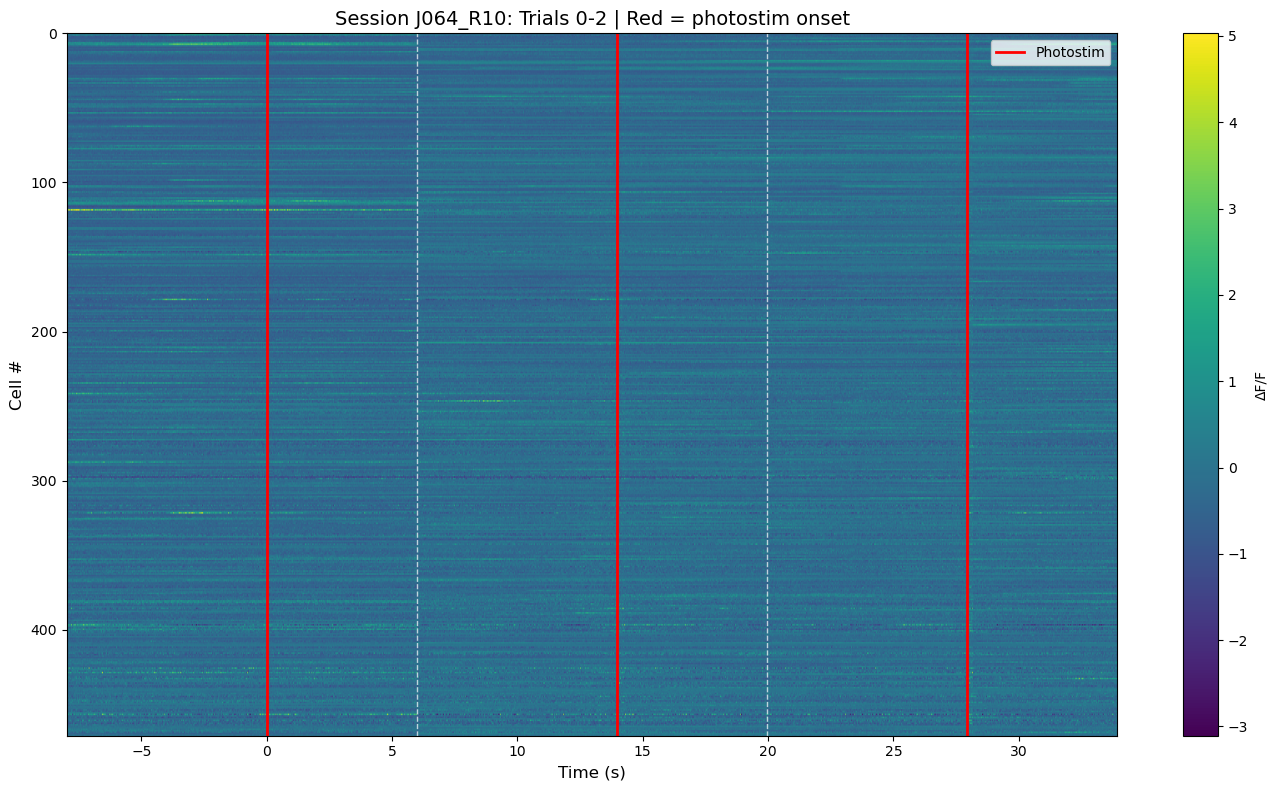

In [4]:
import matplotlib.pyplot as plt


# Get data
neural_data = s0['behaviour_trials']  # (n_cells, n_trials, n_times)
time_array = s0['filter_ps_time']
is_target = s0['is_target']

# Concatenate first 3 trials
n_trials_to_plot = 3
trials_data = [neural_data[:, t, :] for t in range(n_trials_to_plot)]
continuous_data = np.concatenate(trials_data, axis=1)

# Create continuous time axis
trial_duration = time_array[-1] - time_array[0]
continuous_time = np.concatenate([time_array + t * trial_duration for t in range(n_trials_to_plot)])

# Plot heatmap
fig, ax = plt.subplots(figsize=(14, 8))

im = ax.imshow(continuous_data, aspect='auto', cmap='viridis',
               extent=[continuous_time[0], continuous_time[-1], neural_data.shape[0], 0])

# Add red vertical lines for photostimulation onset (t=0 in each trial)
for t in range(n_trials_to_plot):
    stim_time = t * trial_duration
    ax.axvline(x=stim_time, color='red', linestyle='-', linewidth=2, label='Photostim' if t == 0 else '')

# Add dashed lines for trial boundaries
for t in range(1, n_trials_to_plot):
    boundary_time = t * trial_duration + time_array[0]
    ax.axvline(x=boundary_time, color='white', linestyle='--', linewidth=1, alpha=0.7)

ax.set_xlabel('Time (s)', fontsize=12)
ax.set_ylabel('Cell #', fontsize=12)
ax.set_title(f"Session {s0['signature']}: Trials 0-2 | Red = photostim onset", fontsize=14)

plt.colorbar(im, ax=ax, label='ΔF/F')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [5]:
## Get list of targeted neurons for each trial
s0 = sessions[0]

is_target = s0['is_target']  # (n_cells, n_trials, n_times)
trial_subsets = s0['trial_subsets']  # number of cells stimulated per trial

print(f"Session: {s0['signature']}")
print(f"Total trials: {s0['n_trials']}")
print(f"Unique stim conditions: {np.unique(trial_subsets)} cells\n")

# Store targeted neurons for each trial
targeted_neurons_per_trial = {}

for trial_idx in range(s0['n_trials']):
    # Get cells that were targets on this trial (at any timepoint)
    stim_cells = np.where(is_target[:, trial_idx, :].any(axis=1))[0]
    targeted_neurons_per_trial[trial_idx] = stim_cells

# Print summary
print("=" * 60)
print("TARGETED NEURONS PER TRIAL")
print("=" * 60)

for trial_idx in range(s0['n_trials']):
    neurons = targeted_neurons_per_trial[trial_idx]
    outcome = s0['outcome'][trial_idx]
    n_expected = trial_subsets[trial_idx]
    # Convert to native Python ints for clean output
    neurons_list = [int(n) for n in neurons]
    print(f"Trial {trial_idx:3d}: {len(neurons):3d} neurons targeted (expected {n_expected:3d}) | outcome: {outcome:4s} | neurons: {neurons_list}")

# Summary statistics
print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)

# Group trials by number of stimulated cells
for n_stim in np.unique(trial_subsets):
    trials_with_n = np.where(trial_subsets == n_stim)[0]
    print(f"\nTrials with {n_stim} cells stimulated: {len(trials_with_n)} trials")
    
    if n_stim > 0:
        # Get all unique neurons targeted in these trials
        all_targeted = []
        for t in trials_with_n:
            all_targeted.extend(targeted_neurons_per_trial[t])
        unique_targeted = np.unique(all_targeted)
        # Convert to native Python ints for clean output
        unique_targeted_list = [int(n) for n in unique_targeted]
        print(f"  Unique neurons targeted across these trials: {len(unique_targeted)}")
        print(f"  Neuron IDs: {unique_targeted_list[:20]}{'...' if len(unique_targeted) > 20 else ''}")

Session: J064_R10
Total trials: 162
Unique stim conditions: [  0   5  10  20  30  40  50 150] cells

TARGETED NEURONS PER TRIAL
Trial   0:   0 neurons targeted (expected   0) | outcome: fp   | neurons: []
Trial   1:  23 neurons targeted (expected  10) | outcome: miss | neurons: [26, 49, 57, 83, 101, 109, 111, 134, 145, 158, 195, 201, 232, 250, 327, 337, 395, 402, 406, 420, 426, 429, 459]
Trial   2:  99 neurons targeted (expected  50) | outcome: hit  | neurons: [1, 8, 15, 19, 26, 29, 30, 34, 38, 43, 48, 54, 55, 57, 64, 65, 68, 73, 82, 83, 84, 88, 94, 97, 101, 102, 103, 110, 111, 115, 116, 117, 126, 127, 128, 130, 137, 139, 140, 144, 145, 152, 157, 158, 165, 166, 169, 170, 186, 188, 193, 195, 217, 221, 232, 234, 242, 244, 248, 252, 255, 260, 261, 262, 271, 278, 279, 283, 284, 295, 300, 307, 308, 309, 310, 327, 329, 334, 339, 343, 355, 362, 363, 364, 369, 372, 374, 395, 402, 408, 409, 410, 426, 434, 438, 450, 465, 469, 470]
Trial   3: 177 neurons targeted (expected 150) | outcome: hit  | 

In [ ]:
s0['is_target'].shape


# Data under dPCA

In [ ]:
from numpy import *
import matplotlib.pyplot as plt
from dPCA import dPCA
from mpl_toolkits.mplot3d import Axes3D
from numpy.random import rand, randn, randint
# Configure plotting style
plt.style.use('ggplot')
%matplotlib inline

In [ ]:
# PCA analysis for trials 16 and 17 with stimulation markers (smoothed)
from scipy.ndimage import gaussian_filter1d

s0 = sessions[0]

neural_data = s0['behaviour_trials']  # (n_cells, n_trials, n_times)
is_target = s0['is_target']  # (n_cells, n_trials, n_times)
time_array = s0['filter_ps_time']
trial_subsets = s0['trial_subsets']

# Trials to plot
trial_indices_to_plot = [16, 17]

# Trials to use for building PCA space (0 through 17)
trials_for_pca = list(range(18))  # trials 0-17
pca_data = neural_data[:, trials_for_pca, :]  # (n_cells, 18, n_times)

# Find the photostim onset index (t=0)
stim_onset_idx = np.argmin(np.abs(time_array))
print(f"Photostim onset at index {stim_onset_idx} (t = {time_array[stim_onset_idx]:.3f}s)")
print(f"Building PCA space from trials 0-17 ({len(trials_for_pca)} trials)")

# Get stimulation timepoints for trials 16 and 17
stim_timepoints = {}
for trial_idx in trial_indices_to_plot:
    # Find timepoints where any cell was stimulated
    stim_frames = np.where(is_target[:, trial_idx, :].any(axis=0))[0]
    stim_timepoints[trial_idx] = stim_frames
    targeted_neurons = np.where(is_target[:, trial_idx, :].any(axis=1))[0]
    n_stim = trial_subsets[trial_idx]
    print(f"Trial {trial_idx}: {len(targeted_neurons)} neurons targeted (expected {n_stim}), {len(stim_frames)} stim timepoints")
    if len(stim_frames) > 0:
        print(f"  Stim frames: {[int(f) for f in stim_frames[:10]]}{'...' if len(stim_frames) > 10 else ''}")

# Combine all PCA trials for fitting: (n_cells, n_times * n_trials_pca)
X_combined = pca_data.reshape(s0['n_cells'], -1).T  # (n_times * 18, n_cells)

# Center the data
X_mean = X_combined.mean(axis=0)
X_centered = X_combined - X_mean

# Fit PCA to get top 3 components
from sklearn.decomposition import PCA

pca = PCA(n_components=3)
pca.fit(X_centered)

print(f"\nPCA explained variance: {pca.explained_variance_ratio_ * 100}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum() * 100:.1f}%")

# Project trials 16 and 17 into the PCA space and smooth
sigma = 3  # Smoothing parameter (adjust for more/less smoothing)
trajectories = {}
trajectories_smooth = {}
for trial_idx in trial_indices_to_plot:
    trial_data = neural_data[:, trial_idx, :].T  # (n_times, n_cells)
    trial_centered = trial_data - X_mean
    traj = pca.transform(trial_centered)  # (n_times, 3)
    trajectories[trial_idx] = traj
    # Smooth each PC dimension
    traj_smooth = np.zeros_like(traj)
    for dim in range(3):
        traj_smooth[:, dim] = gaussian_filter1d(traj[:, dim], sigma=sigma)
    trajectories_smooth[trial_idx] = traj_smooth

# Plot 3D trajectories
fig = plt.figure(figsize=(14, 6))

# Colors for trajectories and their stim markers
colors = ['blue', 'goldenrod']

# 3D plot
ax1 = fig.add_subplot(121, projection='3d')

for i, trial_idx in enumerate(trial_indices_to_plot):
    traj = trajectories_smooth[trial_idx]
    stim_frames = stim_timepoints[trial_idx]
    
    # Plot smoothed trajectory
    ax1.plot(traj[:, 0], traj[:, 1], traj[:, 2], 
             color=colors[i], alpha=0.8, linewidth=2, label=f'Trial {trial_idx}')
    
    # Mark stimulation timepoints in same color as trajectory (if any)
    if len(stim_frames) > 0:
        ax1.scatter(traj[stim_frames, 0], traj[stim_frames, 1], traj[stim_frames, 2], 
                   color=colors[i], s=30, alpha=0.8, marker='D', label=f'Stim T{trial_idx}')
    
    # Mark photostim ONSET (t=0) with a red star marker
    ax1.scatter(traj[stim_onset_idx, 0], traj[stim_onset_idx, 1], traj[stim_onset_idx, 2], 
               color='red', marker='*', s=150, edgecolor='black', linewidth=0.5,
               label=f'Stim onset' if i == 0 else '', zorder=10)
    
    # Mark start and end (smaller markers)
    ax1.scatter(*traj[0], color=colors[i], marker='o', s=40, edgecolor='black', linewidth=0.5, zorder=5)
    ax1.scatter(*traj[-1], color=colors[i], marker='s', s=40, edgecolor='black', linewidth=0.5, zorder=5)

ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax1.set_zlabel('PC3')
ax1.set_title('3D Neural Trajectories (Top 3 PCs)\nPCA built from trials 0-17\n★ = Stim onset (t=0), ● = Start, ■ = End')
ax1.legend(loc='upper left', fontsize=8)

# 2D plot (PC1 vs PC2)
ax2 = fig.add_subplot(122)

for i, trial_idx in enumerate(trial_indices_to_plot):
    traj = trajectories_smooth[trial_idx]
    stim_frames = stim_timepoints[trial_idx]
    
    # Plot smoothed trajectory
    ax2.plot(traj[:, 0], traj[:, 1], color=colors[i], alpha=0.8, linewidth=2, label=f'Trial {trial_idx}')
    
    # Highlight stimulation timepoints in same color as trajectory (if any)
    if len(stim_frames) > 0:
        ax2.scatter(traj[stim_frames, 0], traj[stim_frames, 1], 
                   color=colors[i], s=50, alpha=0.8, marker='D', zorder=5)
    
    # Mark photostim ONSET (t=0) with a red star marker
    ax2.scatter(traj[stim_onset_idx, 0], traj[stim_onset_idx, 1], 
               color='red', marker='*', s=200, edgecolor='black', linewidth=1,
               label=f'Stim onset (t=0)' if i == 0 else '', zorder=10)
    
    # Mark start and end (smaller markers)
    ax2.scatter(traj[0, 0], traj[0, 1], color=colors[i], marker='o', s=60, edgecolor='black', linewidth=0.5, zorder=6)
    ax2.scatter(traj[-1, 0], traj[-1, 1], color=colors[i], marker='s', s=60, edgecolor='black', linewidth=0.5, zorder=6)

ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.set_title('2D Neural Trajectories (PC1 vs PC2)\nPCA built from trials 0-17\n★ = Stim onset (t=0), ● = Start, ■ = End')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print trial info
for trial_idx in trial_indices_to_plot:
    outcome = s0['outcome'][trial_idx]
    n_stim = trial_subsets[trial_idx]
    print(f"\nTrial {trial_idx}: {n_stim} cells stimulated, outcome: {outcome}")

In [ ]:
# PCA analysis for trials 8 and 9, with PCA space built from trials 0-9
from scipy.ndimage import gaussian_filter1d

s0 = sessions[0]

neural_data = s0['behaviour_trials']  # (n_cells, n_trials, n_times)
is_target = s0['is_target']  # (n_cells, n_trials, n_times)
time_array = s0['filter_ps_time']
trial_subsets = s0['trial_subsets']

# Trials to plot
trial_indices_to_plot = [8, 9]

# Trials to use for building PCA space (0 through 9)
trials_for_pca = list(range(10))  # trials 0-9
pca_data = neural_data[:, trials_for_pca, :]  # (n_cells, 10, n_times)

# Find the photostim onset index (t=0)
stim_onset_idx = np.argmin(np.abs(time_array))
print(f"Photostim onset at index {stim_onset_idx} (t = {time_array[stim_onset_idx]:.3f}s)")
print(f"Building PCA space from trials 0-9 ({len(trials_for_pca)} trials)")

# Get stimulation timepoints for trials 8 and 9
stim_timepoints = {}
for trial_idx in trial_indices_to_plot:
    # Find timepoints where any cell was stimulated
    stim_frames = np.where(is_target[:, trial_idx, :].any(axis=0))[0]
    stim_timepoints[trial_idx] = stim_frames
    targeted_neurons = np.where(is_target[:, trial_idx, :].any(axis=1))[0]
    n_stim = trial_subsets[trial_idx]
    print(f"Trial {trial_idx}: {len(targeted_neurons)} neurons targeted (expected {n_stim}), {len(stim_frames)} stim timepoints")
    if len(stim_frames) > 0:
        print(f"  Stim frames: {[int(f) for f in stim_frames[:10]]}{'...' if len(stim_frames) > 10 else ''}")

# Combine all PCA trials for fitting: (n_cells, n_times * n_trials_pca)
X_combined = pca_data.reshape(s0['n_cells'], -1).T  # (n_times * 10, n_cells)

# Center the data
X_mean = X_combined.mean(axis=0)
X_centered = X_combined - X_mean

# Fit PCA to get top 3 components
from sklearn.decomposition import PCA

pca = PCA(n_components=3)
pca.fit(X_centered)

print(f"\nPCA explained variance: {pca.explained_variance_ratio_ * 100}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum() * 100:.1f}%")

# Project trials 8 and 9 into the PCA space and smooth
sigma = 3  # Smoothing parameter (adjust for more/less smoothing)
trajectories = {}
trajectories_smooth = {}
for trial_idx in trial_indices_to_plot:
    trial_data = neural_data[:, trial_idx, :].T  # (n_times, n_cells)
    trial_centered = trial_data - X_mean
    traj = pca.transform(trial_centered)  # (n_times, 3)
    trajectories[trial_idx] = traj
    # Smooth each PC dimension
    traj_smooth = np.zeros_like(traj)
    for dim in range(3):
        traj_smooth[:, dim] = gaussian_filter1d(traj[:, dim], sigma=sigma)
    trajectories_smooth[trial_idx] = traj_smooth

# Plot 3D trajectories
fig = plt.figure(figsize=(14, 6))

# Colors for trajectories and their stim markers
colors = ['blue', 'goldenrod']

# 3D plot
ax1 = fig.add_subplot(121, projection='3d')

for i, trial_idx in enumerate(trial_indices_to_plot):
    traj = trajectories_smooth[trial_idx]
    stim_frames = stim_timepoints[trial_idx]
    
    # Plot smoothed trajectory
    ax1.plot(traj[:, 0], traj[:, 1], traj[:, 2], 
             color=colors[i], alpha=0.8, linewidth=2, label=f'Trial {trial_idx}')
    
    # Mark stimulation timepoints in same color as trajectory (if any)
    if len(stim_frames) > 0:
        ax1.scatter(traj[stim_frames, 0], traj[stim_frames, 1], traj[stim_frames, 2], 
                   color=colors[i], s=30, alpha=0.8, marker='D', label=f'Stim T{trial_idx}')
    
    # Mark photostim ONSET (t=0) with a red star marker
    ax1.scatter(traj[stim_onset_idx, 0], traj[stim_onset_idx, 1], traj[stim_onset_idx, 2], 
               color='red', marker='*', s=150, edgecolor='black', linewidth=0.5,
               label=f'Stim onset' if i == 0 else '', zorder=10)
    
    # Mark start and end (smaller markers)
    ax1.scatter(*traj[0], color=colors[i], marker='o', s=40, edgecolor='black', linewidth=0.5, zorder=5)
    ax1.scatter(*traj[-1], color=colors[i], marker='s', s=40, edgecolor='black', linewidth=0.5, zorder=5)

ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax1.set_zlabel('PC3')
ax1.set_title('3D Neural Trajectories (Top 3 PCs)\nPCA built from trials 0-9\n★ = Stim onset (t=0), ● = Start, ■ = End')
ax1.legend(loc='upper left', fontsize=8)

# 2D plot (PC1 vs PC2)
ax2 = fig.add_subplot(122)

for i, trial_idx in enumerate(trial_indices_to_plot):
    traj = trajectories_smooth[trial_idx]
    stim_frames = stim_timepoints[trial_idx]
    
    # Plot smoothed trajectory
    ax2.plot(traj[:, 0], traj[:, 1], color=colors[i], alpha=0.8, linewidth=2, label=f'Trial {trial_idx}')
    
    # Highlight stimulation timepoints in same color as trajectory (if any)
    if len(stim_frames) > 0:
        ax2.scatter(traj[stim_frames, 0], traj[stim_frames, 1], 
                   color=colors[i], s=50, alpha=0.8, marker='D', zorder=5)
    
    # Mark photostim ONSET (t=0) with a red star marker
    ax2.scatter(traj[stim_onset_idx, 0], traj[stim_onset_idx, 1], 
               color='red', marker='*', s=200, edgecolor='black', linewidth=1,
               label=f'Stim onset (t=0)' if i == 0 else '', zorder=10)
    
    # Mark start and end (smaller markers)
    ax2.scatter(traj[0, 0], traj[0, 1], color=colors[i], marker='o', s=60, edgecolor='black', linewidth=0.5, zorder=6)
    ax2.scatter(traj[-1, 0], traj[-1, 1], color=colors[i], marker='s', s=60, edgecolor='black', linewidth=0.5, zorder=6)

ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.set_title('2D Neural Trajectories (PC1 vs PC2)\nPCA built from trials 0-9\n★ = Stim onset (t=0), ● = Start, ■ = End')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print trial info
for trial_idx in trial_indices_to_plot:
    outcome = s0['outcome'][trial_idx]
    n_stim = trial_subsets[trial_idx]
    print(f"\nTrial {trial_idx}: {n_stim} cells stimulated, outcome: {outcome}")

In [ ]:
# PCA analysis for trials 9 and 10, with PCA space built from trials 0-10 (smoothed)
from scipy.ndimage import gaussian_filter1d

s0 = sessions[0]

neural_data = s0['behaviour_trials']  # (n_cells, n_trials, n_times)
is_target = s0['is_target']  # (n_cells, n_trials, n_times)
time_array = s0['filter_ps_time']
trial_subsets = s0['trial_subsets']

# Trials to plot
trial_indices_to_plot = [9, 10]

# Trials to use for building PCA space (0 through 10)
trials_for_pca = list(range(11))  # trials 0-10
pca_data = neural_data[:, trials_for_pca, :]  # (n_cells, 11, n_times)

# Find the photostim onset index (t=0)
stim_onset_idx = np.argmin(np.abs(time_array))
print(f"Photostim onset at index {stim_onset_idx} (t = {time_array[stim_onset_idx]:.3f}s)")
print(f"Building PCA space from trials 0-10 ({len(trials_for_pca)} trials)")

# Get stimulation timepoints for trials 9 and 10
stim_timepoints = {}
for trial_idx in trial_indices_to_plot:
    # Find timepoints where any cell was stimulated
    stim_frames = np.where(is_target[:, trial_idx, :].any(axis=0))[0]
    stim_timepoints[trial_idx] = stim_frames
    targeted_neurons = np.where(is_target[:, trial_idx, :].any(axis=1))[0]
    n_stim = trial_subsets[trial_idx]
    print(f"Trial {trial_idx}: {len(targeted_neurons)} neurons targeted (expected {n_stim}), {len(stim_frames)} stim timepoints")
    if len(stim_frames) > 0:
        print(f"  Stim frames: {[int(f) for f in stim_frames[:10]]}{'...' if len(stim_frames) > 10 else ''}")

# Combine all PCA trials for fitting: (n_cells, n_times * n_trials_pca)
X_combined = pca_data.reshape(s0['n_cells'], -1).T  # (n_times * 11, n_cells)

# Center the data
X_mean = X_combined.mean(axis=0)
X_centered = X_combined - X_mean

# Fit PCA to get top 3 components
from sklearn.decomposition import PCA

pca = PCA(n_components=3)
pca.fit(X_centered)

print(f"\nPCA explained variance: {pca.explained_variance_ratio_ * 100}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum() * 100:.1f}%")

# Project trials 9 and 10 into the PCA space and smooth
sigma = 3  # Smoothing parameter (adjust for more/less smoothing)
trajectories = {}
trajectories_smooth = {}
for trial_idx in trial_indices_to_plot:
    trial_data = neural_data[:, trial_idx, :].T  # (n_times, n_cells)
    trial_centered = trial_data - X_mean
    traj = pca.transform(trial_centered)  # (n_times, 3)
    trajectories[trial_idx] = traj
    # Smooth each PC dimension
    traj_smooth = np.zeros_like(traj)
    for dim in range(3):
        traj_smooth[:, dim] = gaussian_filter1d(traj[:, dim], sigma=sigma)
    trajectories_smooth[trial_idx] = traj_smooth

# Plot 3D trajectories
fig = plt.figure(figsize=(14, 6))

# Colors for trajectories and their stim markers
colors = ['blue', 'goldenrod']

# 3D plot
ax1 = fig.add_subplot(121, projection='3d')

for i, trial_idx in enumerate(trial_indices_to_plot):
    traj = trajectories_smooth[trial_idx]
    stim_frames = stim_timepoints[trial_idx]
    
    # Plot smoothed trajectory
    ax1.plot(traj[:, 0], traj[:, 1], traj[:, 2], 
             color=colors[i], alpha=0.8, linewidth=2, label=f'Trial {trial_idx}')
    
    # Mark stimulation timepoints in same color as trajectory (if any)
    if len(stim_frames) > 0:
        ax1.scatter(traj[stim_frames, 0], traj[stim_frames, 1], traj[stim_frames, 2], 
                   color=colors[i], s=30, alpha=0.8, marker='D', label=f'Stim T{trial_idx}')
    
    # Mark photostim ONSET (t=0) with a red star marker
    ax1.scatter(traj[stim_onset_idx, 0], traj[stim_onset_idx, 1], traj[stim_onset_idx, 2], 
               color='red', marker='*', s=150, edgecolor='black', linewidth=0.5,
               label=f'Stim onset' if i == 0 else '', zorder=10)
    
    # Mark start and end (smaller markers)
    ax1.scatter(*traj[0], color=colors[i], marker='o', s=40, edgecolor='black', linewidth=0.5, zorder=5)
    ax1.scatter(*traj[-1], color=colors[i], marker='s', s=40, edgecolor='black', linewidth=0.5, zorder=5)

ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax1.set_zlabel('PC3')
ax1.set_title('3D Neural Trajectories (Top 3 PCs)\nPCA built from trials 0-10\n★ = Stim onset (t=0), ● = Start, ■ = End')
ax1.legend(loc='upper left', fontsize=8)

# 2D plot (PC1 vs PC2)
ax2 = fig.add_subplot(122)

for i, trial_idx in enumerate(trial_indices_to_plot):
    traj = trajectories_smooth[trial_idx]
    stim_frames = stim_timepoints[trial_idx]
    
    # Plot smoothed trajectory
    ax2.plot(traj[:, 0], traj[:, 1], color=colors[i], alpha=0.8, linewidth=2, label=f'Trial {trial_idx}')
    
    # Highlight stimulation timepoints in same color as trajectory (if any)
    if len(stim_frames) > 0:
        ax2.scatter(traj[stim_frames, 0], traj[stim_frames, 1], 
                   color=colors[i], s=50, alpha=0.8, marker='D', zorder=5)
    
    # Mark photostim ONSET (t=0) with a red star marker
    ax2.scatter(traj[stim_onset_idx, 0], traj[stim_onset_idx, 1], 
               color='red', marker='*', s=200, edgecolor='black', linewidth=1,
               label=f'Stim onset (t=0)' if i == 0 else '', zorder=10)
    
    # Mark start and end (smaller markers)
    ax2.scatter(traj[0, 0], traj[0, 1], color=colors[i], marker='o', s=60, edgecolor='black', linewidth=0.5, zorder=6)
    ax2.scatter(traj[-1, 0], traj[-1, 1], color=colors[i], marker='s', s=60, edgecolor='black', linewidth=0.5, zorder=6)

ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.set_title('2D Neural Trajectories (PC1 vs PC2)\nPCA built from trials 0-10\n★ = Stim onset (t=0), ● = Start, ■ = End')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print trial info
for trial_idx in trial_indices_to_plot:
    outcome = s0['outcome'][trial_idx]
    n_stim = trial_subsets[trial_idx]
    print(f"\nTrial {trial_idx}: {n_stim} cells stimulated, outcome: {outcome}")

In [ ]:
# Average fluorescence change for trials 9 and 10
import builtins

s0 = sessions[0]
neural_data = s0['behaviour_trials']  # (n_cells, n_trials, n_times)
is_target = s0['is_target']
time_array = s0['filter_ps_time']
trial_subsets = s0['trial_subsets']

# Find photostim onset index (t=0)
stim_onset_idx = int(np.argmin(np.abs(time_array)))

# Define pre-stim and post-stim windows (in frames)
pre_window = 10  # frames before stim
post_window = 30  # frames after stim

# Trials to analyze
trial_indices = [9, 10]
colors_trials = ['blue', 'goldenrod']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# For each trial, compute average fluorescence over time for all neurons, targeted, and non-targeted
for i, trial_idx in enumerate(trial_indices):
    trial_data = neural_data[:, trial_idx, :]  # (n_cells, n_times)
    targeted_neurons = np.where(is_target[:, trial_idx, :].any(axis=1))[0]
    non_targeted = np.setdiff1d(np.arange(s0['n_cells']), targeted_neurons)
    
    n_stim = trial_subsets[trial_idx]
    outcome = s0['outcome'][trial_idx]
    
    # Compute mean fluorescence over time
    avg_all = trial_data.mean(axis=0)  # average over all neurons
    avg_targeted = trial_data[targeted_neurons, :].mean(axis=0) if len(targeted_neurons) > 0 else np.zeros(s0['n_times'])
    avg_non_targeted = trial_data[non_targeted, :].mean(axis=0) if len(non_targeted) > 0 else np.zeros(s0['n_times'])
    
    # Plot 1: All neurons
    axes[0].plot(time_array, avg_all, color=colors_trials[i], linewidth=2, 
                 label=f'Trial {trial_idx} ({n_stim} stim, {outcome})')
    
    # Plot 2: Targeted neurons
    if len(targeted_neurons) > 0:
        axes[1].plot(time_array, avg_targeted, color=colors_trials[i], linewidth=2,
                     label=f'Trial {trial_idx} ({len(targeted_neurons)} targeted)')
    
    # Plot 3: Non-targeted neurons
    axes[2].plot(time_array, avg_non_targeted, color=colors_trials[i], linewidth=2,
                 label=f'Trial {trial_idx} ({len(non_targeted)} non-targeted)')

# Add vertical line for stim onset
for ax in axes:
    ax.axvline(x=0, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Stim onset')
    ax.set_xlabel('Time (s)', fontsize=12)
    ax.set_ylabel('Avg ΔF/F', fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

axes[0].set_title('All Neurons', fontsize=12)
axes[1].set_title('Targeted Neurons Only', fontsize=12)
axes[2].set_title('Non-Targeted Neurons', fontsize=12)

plt.suptitle(f"Session {s0['signature']}: Average Fluorescence - Trials 9 & 10", fontsize=14)
plt.tight_layout()
plt.show()

# Print summary
print("\nSUMMARY:")
for trial_idx in trial_indices:
    trial_data = neural_data[:, trial_idx, :]
    targeted_neurons = np.where(is_target[:, trial_idx, :].any(axis=1))[0]
    non_targeted = np.setdiff1d(np.arange(s0['n_cells']), targeted_neurons)
    
    # Calculate ΔF/F change
    pre_start = builtins.max(0, stim_onset_idx - pre_window)
    baseline = trial_data[:, pre_start:stim_onset_idx].mean(axis=1)
    post_stim = trial_data[:, stim_onset_idx:stim_onset_idx+post_window].mean(axis=1)
    delta_f = post_stim - baseline
    
    n_stim = trial_subsets[trial_idx]
    outcome = s0['outcome'][trial_idx]
    print(f"\nTrial {trial_idx}: {n_stim} neurons stimulated, outcome: {outcome}")
    print(f"  Avg ΔF/F (all neurons):        {delta_f.mean():.4f}")
    if len(targeted_neurons) > 0:
        print(f"  Avg ΔF/F (targeted neurons):   {delta_f[targeted_neurons].mean():.4f}")
    print(f"  Avg ΔF/F (non-targeted):       {delta_f[non_targeted].mean():.4f}")

In [ ]:
# Photostimulation parametrization: Number of neurons stimulated vs fluorescence change
s0 = sessions[0]

neural_data = s0['behaviour_trials']  # (n_cells, n_trials, n_times)
is_target = s0['is_target']  # (n_cells, n_trials, n_times)
time_array = s0['filter_ps_time']
trial_subsets = s0['trial_subsets']

# Find photostim onset index (t=0)
stim_onset_idx = int(np.argmin(np.abs(time_array)))

# Define pre-stim and post-stim windows (in frames)
pre_window = 10  # frames before stim
post_window = 30  # frames after stim

print(f"Stim onset index: {stim_onset_idx}")
print(f"Pre-stim window: {pre_window} frames ({pre_window / s0['frequency']:.3f}s)")
print(f"Post-stim window: {post_window} frames ({post_window / s0['frequency']:.3f}s)")

# Collect data for each trial
n_neurons_stimulated = []
avg_fluorescence_change_all = []
avg_fluorescence_change_targeted = []
avg_fluorescence_change_non_targeted = []
outcomes = []

for trial_idx in range(s0['n_trials']):
    # Number of neurons stimulated
    targeted_neurons = np.where(is_target[:, trial_idx, :].any(axis=1))[0]
    n_stim = len(targeted_neurons)
    n_neurons_stimulated.append(n_stim)
    
    # Get trial data
    trial_data = neural_data[:, trial_idx, :]  # (n_cells, n_times)
    
    # Calculate baseline (pre-stim) and post-stim activity
    # Use builtins.max/min because 'from numpy import *' overwrote them
    import builtins
    pre_start = builtins.max(0, stim_onset_idx - pre_window)
    pre_end = stim_onset_idx
    post_start = stim_onset_idx
    post_end = builtins.min(s0['n_times'], stim_onset_idx + post_window)
    
    baseline = trial_data[:, pre_start:pre_end].mean(axis=1)  # (n_cells,)
    post_stim = trial_data[:, post_start:post_end].mean(axis=1)  # (n_cells,)
    
    # Fluorescence change (post - baseline)
    delta_f = post_stim - baseline
    
    # Average across all neurons
    avg_fluorescence_change_all.append(delta_f.mean())
    
    # Average for targeted neurons only
    if n_stim > 0:
        avg_fluorescence_change_targeted.append(delta_f[targeted_neurons].mean())
    else:
        avg_fluorescence_change_targeted.append(np.nan)
    
    # Average for non-targeted neurons
    non_targeted = np.setdiff1d(np.arange(s0['n_cells']), targeted_neurons)
    if len(non_targeted) > 0:
        avg_fluorescence_change_non_targeted.append(delta_f[non_targeted].mean())
    else:
        avg_fluorescence_change_non_targeted.append(np.nan)
    
    outcomes.append(s0['outcome'][trial_idx])

n_neurons_stimulated = np.array(n_neurons_stimulated)
avg_fluorescence_change_all = np.array(avg_fluorescence_change_all)
avg_fluorescence_change_targeted = np.array(avg_fluorescence_change_targeted)
avg_fluorescence_change_non_targeted = np.array(avg_fluorescence_change_non_targeted)
outcomes = np.array(outcomes)

# Create figure with multiple plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Color by outcome
outcome_colors = {'hit': 'green', 'miss': 'red', 'fa': 'orange', 'cr': 'blue'}
colors = [outcome_colors.get(o, 'gray') for o in outcomes]

# Plot 1: N neurons vs avg ΔF/F (all neurons)
ax1 = axes[0, 0]
for outcome in np.unique(outcomes):
    mask = outcomes == outcome
    ax1.scatter(n_neurons_stimulated[mask], avg_fluorescence_change_all[mask], 
               c=outcome_colors.get(outcome, 'gray'), label=outcome, alpha=0.7, s=50)
ax1.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax1.set_xlabel('Number of neurons stimulated', fontsize=12)
ax1.set_ylabel('Avg ΔF/F (all neurons)', fontsize=12)
ax1.set_title('All Neurons: N stim vs Fluorescence Change', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: N neurons vs avg ΔF/F (targeted neurons only)
ax2 = axes[0, 1]
for outcome in np.unique(outcomes):
    mask = (outcomes == outcome) & ~np.isnan(avg_fluorescence_change_targeted)
    ax2.scatter(n_neurons_stimulated[mask], avg_fluorescence_change_targeted[mask], 
               c=outcome_colors.get(outcome, 'gray'), label=outcome, alpha=0.7, s=50)
ax2.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax2.set_xlabel('Number of neurons stimulated', fontsize=12)
ax2.set_ylabel('Avg ΔF/F (targeted neurons)', fontsize=12)
ax2.set_title('Targeted Neurons Only: N stim vs Fluorescence Change', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: N neurons vs avg ΔF/F (non-targeted neurons)
ax3 = axes[1, 0]
for outcome in np.unique(outcomes):
    mask = (outcomes == outcome) & ~np.isnan(avg_fluorescence_change_non_targeted)
    ax3.scatter(n_neurons_stimulated[mask], avg_fluorescence_change_non_targeted[mask], 
               c=outcome_colors.get(outcome, 'gray'), label=outcome, alpha=0.7, s=50)
ax3.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax3.set_xlabel('Number of neurons stimulated', fontsize=12)
ax3.set_ylabel('Avg ΔF/F (non-targeted neurons)', fontsize=12)
ax3.set_title('Non-Targeted Neurons: N stim vs Fluorescence Change', fontsize=12)
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Box plot by stimulation condition
ax4 = axes[1, 1]
unique_stim = np.unique(n_neurons_stimulated)
box_data = [avg_fluorescence_change_all[n_neurons_stimulated == n] for n in unique_stim]
bp = ax4.boxplot(box_data, positions=unique_stim, widths=3, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
    patch.set_alpha(0.7)
ax4.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax4.set_xlabel('Number of neurons stimulated', fontsize=12)
ax4.set_ylabel('Avg ΔF/F (all neurons)', fontsize=12)
ax4.set_title('Distribution of Fluorescence Change by Stim Condition', fontsize=12)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle(f"Session {s0['signature']}: Photostimulation Parametrization", fontsize=14, y=1.02)
plt.show()


In [ ]:
# Calculate path distance from stim onset to end of trial for trials 16 and 17
from scipy.ndimage import gaussian_filter1d
from sklearn.decomposition import PCA

s0 = sessions[0]

neural_data = s0['behaviour_trials']  # (n_cells, n_trials, n_times)
time_array = s0['filter_ps_time']
trial_subsets = s0['trial_subsets']

# Trials to analyze
trial_indices = [16, 17]

# Trials to use for building PCA space (0 through 17)
trials_for_pca = list(range(18))
pca_data = neural_data[:, trials_for_pca, :]

# Find the photostim onset index (t=0)
stim_onset_idx = np.argmin(np.abs(time_array))

# Combine all PCA trials for fitting
X_combined = pca_data.reshape(s0['n_cells'], -1).T
X_mean = X_combined.mean(axis=0)
X_centered = X_combined - X_mean

# Fit PCA
pca = PCA(n_components=3)
pca.fit(X_centered)

# Smoothing parameter
sigma = 3

# Calculate path distances
print("=" * 60)
print("PATH DISTANCE FROM STIM ONSET TO END OF TRIAL")
print("=" * 60)
print(f"Stim onset at index {stim_onset_idx} (t = {time_array[stim_onset_idx]:.3f}s)")
print(f"End of trial at index {s0['n_times']-1} (t = {time_array[-1]:.3f}s)")
print(f"Number of timepoints from stim onset to end: {s0['n_times'] - stim_onset_idx}")
print()

path_distances = {}

for trial_idx in trial_indices:
    # Project trial into PCA space
    trial_data = neural_data[:, trial_idx, :].T  # (n_times, n_cells)
    trial_centered = trial_data - X_mean
    traj = pca.transform(trial_centered)  # (n_times, 3)
    
    # Smooth trajectory
    traj_smooth = np.zeros_like(traj)
    for dim in range(3):
        traj_smooth[:, dim] = gaussian_filter1d(traj[:, dim], sigma=sigma)
    
    # Calculate path distance from stim onset to end
    # Path distance = sum of Euclidean distances between consecutive points
    traj_post_stim = traj_smooth[stim_onset_idx:, :]  # from stim onset to end
    
    # Calculate distances between consecutive points
    diffs = np.diff(traj_post_stim, axis=0)  # (n_points-1, 3)
    distances = np.sqrt((diffs ** 2).sum(axis=1))  # Euclidean distance for each step
    
    path_distance = distances.sum()
    path_distances[trial_idx] = path_distance
    
    # Also calculate for raw (unsmoothed) trajectory
    traj_post_stim_raw = traj[stim_onset_idx:, :]
    diffs_raw = np.diff(traj_post_stim_raw, axis=0)
    distances_raw = np.sqrt((diffs_raw ** 2).sum(axis=1))
    path_distance_raw = distances_raw.sum()
    
    outcome = s0['outcome'][trial_idx]
    n_stim = trial_subsets[trial_idx]
    
    print(f"Trial {trial_idx}:")
    print(f"  - Neurons stimulated: {n_stim}")
    print(f"  - Outcome: {outcome}")
    print(f"  - Path distance (smoothed, σ={sigma}): {path_distance:.4f}")
    print(f"  - Path distance (raw): {path_distance_raw:.4f}")
    print()

# Compare
print("=" * 60)
print("COMPARISON")
print("=" * 60)
diff = path_distances[17] - path_distances[16]
ratio = path_distances[17] / path_distances[16] if path_distances[16] != 0 else np.inf
print(f"Trial 17 path distance - Trial 16 path distance: {diff:.4f}")
print(f"Trial 17 / Trial 16 ratio: {ratio:.4f}")

In [ ]:
# 3D PCA visualization: stim onset locations colored by path distance, sized by n_neurons
from scipy.ndimage import gaussian_filter1d
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm
from matplotlib.colors import Normalize

s0 = sessions[0]

neural_data = s0['behaviour_trials']  # (n_cells, n_trials, n_times)
time_array = s0['filter_ps_time']
trial_subsets = s0['trial_subsets']
is_target = s0['is_target']

# Trials to analyze (all trials in the session)
n_trials_to_use = s0['n_trials']
trial_indices = list(range(n_trials_to_use))

# Build PCA space from these trials
trials_for_pca = trial_indices
pca_data = neural_data[:, trials_for_pca, :]

# Find the photostim onset index (t=0)
stim_onset_idx = np.argmin(np.abs(time_array))

# Combine all PCA trials for fitting
X_combined = pca_data.reshape(s0['n_cells'], -1).T
X_mean = X_combined.mean(axis=0)
X_centered = X_combined - X_mean

# Fit PCA
pca = PCA(n_components=3)
pca.fit(X_centered)

# Smoothing parameter
sigma = 3

# Calculate path distances and stim onset positions for each trial
stim_onset_positions = []
path_distances = []
n_neurons_stimulated = []
outcomes = []

for trial_idx in trial_indices:
    # Get number of neurons stimulated
    targeted_neurons = np.where(is_target[:, trial_idx, :].any(axis=1))[0]
    n_stim = len(targeted_neurons)
    n_neurons_stimulated.append(n_stim)
    outcomes.append(s0['outcome'][trial_idx])
    
    # Project trial into PCA space
    trial_data = neural_data[:, trial_idx, :].T  # (n_times, n_cells)
    trial_centered = trial_data - X_mean
    traj = pca.transform(trial_centered)  # (n_times, 3)
    
    # Smooth trajectory
    traj_smooth = np.zeros_like(traj)
    for dim in range(3):
        traj_smooth[:, dim] = gaussian_filter1d(traj[:, dim], sigma=sigma)
    
    # Store stim onset position (smoothed)
    stim_onset_positions.append(traj_smooth[stim_onset_idx, :])
    
    # Calculate path distance from stim onset to end
    traj_post_stim = traj_smooth[stim_onset_idx:, :]
    diffs = np.diff(traj_post_stim, axis=0)
    distances = np.sqrt((diffs ** 2).sum(axis=1))
    path_distance = distances.sum()
    path_distances.append(path_distance)

stim_onset_positions = np.array(stim_onset_positions)
path_distances = np.array(path_distances)
n_neurons_stimulated = np.array(n_neurons_stimulated)
outcomes = np.array(outcomes)

# Filter out 'arm' outcomes
arm_mask = outcomes != 'arm'
stim_onset_positions = stim_onset_positions[arm_mask]
path_distances = path_distances[arm_mask]
n_neurons_stimulated = n_neurons_stimulated[arm_mask]
outcomes = outcomes[arm_mask]

# Normalize sizes: scale n_neurons to reasonable marker sizes
# Map 0 neurons -> small size, max neurons -> large size
min_size = 30
max_size = 400
if n_neurons_stimulated.max() > n_neurons_stimulated.min():
    sizes = min_size + (max_size - min_size) * (n_neurons_stimulated - n_neurons_stimulated.min()) / (n_neurons_stimulated.max() - n_neurons_stimulated.min())
else:
    sizes = np.ones_like(n_neurons_stimulated) * (min_size + max_size) / 2

# Create colormap for path distances
norm = Normalize(vmin=path_distances.min(), vmax=path_distances.max())
cmap = cm.viridis

# Define markers for each outcome
outcome_markers = {'hit': 'o', 'miss': 's', 'fa': '^', 'cr': 'D', 'fp': 'X', 'arm': 'P'}
outcome_labels = {'hit': 'Hit', 'miss': 'Miss', 'fa': 'False Alarm', 'cr': 'Correct Rejection', 'fp': 'False Positive', 'arm': 'Arm'}

# Create 3D plot
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot each outcome type separately to get different markers
for outcome_type in np.unique(outcomes):
    mask = outcomes == outcome_type
    marker = outcome_markers.get(outcome_type, 'o')
    
    sc = ax.scatter(stim_onset_positions[mask, 0], 
                    stim_onset_positions[mask, 1], 
                    stim_onset_positions[mask, 2],
                    c=path_distances[mask], 
                    s=sizes[mask], 
                    cmap=cmap, 
                    norm=norm,
                    alpha=0.8, 
                    edgecolors='black', 
                    linewidth=0.5,
                    marker=marker,
                    label=outcome_labels.get(outcome_type, outcome_type))

# Add colorbar (use a scalar mappable for consistent colorbar)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.6, pad=0.1)
cbar.set_label('Path Distance (smoothed, σ=3)', fontsize=12)

# Labels
ax.set_xlabel('PC1', fontsize=12)
ax.set_ylabel('PC2', fontsize=12)
ax.set_zlabel('PC3', fontsize=12)
ax.set_title(f"Stim Onset Positions in PCA Space (All {n_trials_to_use} Trials)\n"
             f"Marker size = # neurons stimulated | Color = path distance\n"
             f"Marker shape = behavioral outcome",
             fontsize=12)

# Add legend for outcome shapes with uniform size and color
legend = ax.legend(loc='upper left', fontsize=9, title='Outcome', markerscale=1)
# Make all legend markers the same size and color (gray)
for handle in legend.legend_handles:
    handle.set_sizes([80])  # uniform size
    handle.set_facecolor('gray')  # uniform face color
    handle.set_edgecolor('black')
    handle.set_array(None)  # remove colormap

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "=" * 60)
print("SUMMARY STATISTICS")
print("=" * 60)
print(f"Number of trials: {n_trials_to_use}")
print(f"Neurons stimulated: min={n_neurons_stimulated.min()}, max={n_neurons_stimulated.max()}")
print(f"Path distances: min={path_distances.min():.2f}, max={path_distances.max():.2f}, mean={path_distances.mean():.2f}")

# Show correlation between n_neurons and path distance
correlation = np.corrcoef(n_neurons_stimulated, path_distances)[0, 1]
print(f"\nCorrelation (n_neurons vs path_distance): {correlation:.3f}")

# Breakdown by outcome
print("\n" + "=" * 60)
print("BREAKDOWN BY OUTCOME")
print("=" * 60)
for outcome_type in np.unique(outcomes):
    mask = outcomes == outcome_type
    print(f"\n{outcome_type.upper()} ({mask.sum()} trials):")
    print(f"  Avg neurons stimulated: {n_neurons_stimulated[mask].mean():.1f}")
    print(f"  Avg path distance: {path_distances[mask].mean():.2f}")

In [ ]:
# 2D PCA visualization with direction color wheel for post-stim trajectory (Session 0)
from scipy.ndimage import gaussian_filter1d
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize, hsv_to_rgb
import matplotlib.patches as mpatches
import builtins

s0 = sessions[0]

neural_data = s0['behaviour_trials']
time_array = s0['filter_ps_time']
trial_subsets = s0['trial_subsets']
is_target = s0['is_target']

n_trials_to_use = s0['n_trials']
trial_indices = list(range(n_trials_to_use))

trials_for_pca = trial_indices
pca_data = neural_data[:, trials_for_pca, :]

stim_onset_idx = np.argmin(np.abs(time_array))

X_combined = pca_data.reshape(s0['n_cells'], -1).T
X_mean = X_combined.mean(axis=0)
X_centered = X_combined - X_mean

pca = PCA(n_components=2)
pca.fit(X_centered)

sigma = 3
n_timesteps_direction = 10  # Number of timesteps after stim to compute direction

# Calculate data for each trial
stim_onset_positions = []
path_distances = []
n_neurons_stimulated = []
outcomes = []
directions_2d = []  # Direction angle in PC1-PC2 plane
direction_vectors = []  # Actual displacement vectors

for trial_idx in trial_indices:
    targeted_neurons = np.where(is_target[:, trial_idx, :].any(axis=1))[0]
    n_stim = len(targeted_neurons)
    n_neurons_stimulated.append(n_stim)
    outcomes.append(s0['outcome'][trial_idx])
    
    trial_data = neural_data[:, trial_idx, :].T
    trial_centered = trial_data - X_mean
    traj = pca.transform(trial_centered)
    
    traj_smooth = np.zeros_like(traj)
    for dim in range(2):
        traj_smooth[:, dim] = gaussian_filter1d(traj[:, dim], sigma=sigma)
    
    stim_onset_positions.append(traj_smooth[stim_onset_idx, :])
    
    # Calculate direction: displacement from stim onset to n_timesteps later
    end_idx = builtins.min(stim_onset_idx + n_timesteps_direction, len(traj_smooth) - 1)
    displacement = traj_smooth[end_idx, :] - traj_smooth[stim_onset_idx, :]
    direction_vectors.append(displacement)
    
    # Calculate angle in PC1-PC2 plane (0 to 2π)
    angle = np.arctan2(displacement[1], displacement[0])  # atan2(PC2, PC1)
    directions_2d.append(angle)
    
    # Path distance
    traj_post_stim = traj_smooth[stim_onset_idx:, :]
    diffs = np.diff(traj_post_stim, axis=0)
    distances = np.sqrt((diffs ** 2).sum(axis=1))
    path_distances.append(distances.sum())

stim_onset_positions = np.array(stim_onset_positions)
path_distances = np.array(path_distances)
n_neurons_stimulated = np.array(n_neurons_stimulated)
outcomes = np.array(outcomes)
directions_2d = np.array(directions_2d)
direction_vectors = np.array(direction_vectors)

# Filter out 'arm' outcomes
arm_mask = outcomes != 'arm'
stim_onset_positions = stim_onset_positions[arm_mask]
path_distances = path_distances[arm_mask]
n_neurons_stimulated = n_neurons_stimulated[arm_mask]
outcomes = outcomes[arm_mask]
directions_2d = directions_2d[arm_mask]
direction_vectors = direction_vectors[arm_mask]

# Normalize sizes
min_size = 50
max_size = 400
if n_neurons_stimulated.max() > n_neurons_stimulated.min():
    sizes = min_size + (max_size - min_size) * (n_neurons_stimulated - n_neurons_stimulated.min()) / (n_neurons_stimulated.max() - n_neurons_stimulated.min())
else:
    sizes = np.ones_like(n_neurons_stimulated) * (min_size + max_size) / 2

# Convert angle to color using HSV color wheel
# Map angle (-π to π) to hue (0 to 1)
hues = (directions_2d + np.pi) / (2 * np.pi)  # Normalize to 0-1
colors_hsv = np.column_stack([hues, np.ones_like(hues), np.ones_like(hues)])  # Full saturation & value
colors_rgb = np.array([hsv_to_rgb(c) for c in colors_hsv])

# Define markers for each outcome
outcome_markers = {'hit': 'o', 'miss': 's', 'fa': '^', 'cr': 'D', 'fp': 'X', 'urh': 'v'}
outcome_labels = {'hit': 'Hit', 'miss': 'Miss', 'fa': 'False Alarm', 'cr': 'Correct Rejection', 
                  'fp': 'False Positive', 'urh': 'Unrewarded Hit'}

# Create figure with main plot and color wheel
fig = plt.figure(figsize=(14, 6))

# Main 2D plot
ax = fig.add_subplot(121)

# Plot each outcome type separately
for outcome_type in np.unique(outcomes):
    mask = outcomes == outcome_type
    marker = outcome_markers.get(outcome_type, 'o')
    
    # Plot points one by one to get individual colors
    for i in np.where(mask)[0]:
        ax.scatter(stim_onset_positions[i, 0], 
                   stim_onset_positions[i, 1], 
                   c=[colors_rgb[i]], 
                   s=sizes[i], 
                   alpha=0.8, 
                   edgecolors='black', 
                   linewidth=0.5,
                   marker=marker)

# Add arrows showing direction
arrow_scale = 0.5
for i in range(len(stim_onset_positions)):
    ax.annotate('', 
                xy=(stim_onset_positions[i, 0] + direction_vectors[i, 0] * arrow_scale,
                    stim_onset_positions[i, 1] + direction_vectors[i, 1] * arrow_scale),
                xytext=(stim_onset_positions[i, 0], stim_onset_positions[i, 1]),
                arrowprops=dict(arrowstyle='->', color=colors_rgb[i], lw=1.5, alpha=0.7))

ax.set_xlabel('PC1', fontsize=12)
ax.set_ylabel('PC2', fontsize=12)
ax.set_title(f"Session 0 ({s0['signature']}): Stim Onset Positions (PC1-PC2)\n"
             f"Color = direction ({n_timesteps_direction} frames post-stim)\n"
             f"Size = # neurons | Shape = outcome | Arrows = trajectory direction",
             fontsize=11)
ax.grid(True, alpha=0.3)

# Create legend for outcomes
legend_handles = []
for outcome_type in np.unique(outcomes):
    marker = outcome_markers.get(outcome_type, 'o')
    handle = plt.Line2D([0], [0], marker=marker, color='w', markerfacecolor='gray', 
                        markeredgecolor='black', markersize=10, linestyle='None',
                        label=outcome_labels.get(outcome_type, outcome_type))
    legend_handles.append(handle)
ax.legend(handles=legend_handles, loc='upper left', fontsize=9, title='Outcome')

# Color wheel subplot
ax_wheel = fig.add_subplot(122, projection='polar')

# Create color wheel
theta = np.linspace(0, 2*np.pi, 256)
r = np.linspace(0.5, 1, 2)
Theta, R = np.meshgrid(theta, r)

ax_wheel.pcolormesh(Theta, R, Theta, cmap='hsv', shading='auto')
ax_wheel.set_yticks([])
ax_wheel.set_title('Direction Color Wheel\n(PC1-PC2 plane)', fontsize=12, pad=20)

# Add direction labels
ax_wheel.annotate('+PC1', xy=(0, 1.2), ha='center', fontsize=11, fontweight='bold')
ax_wheel.annotate('+PC2', xy=(np.pi/2, 1.2), ha='center', fontsize=11, fontweight='bold')
ax_wheel.annotate('-PC1', xy=(np.pi, 1.2), ha='center', fontsize=11, fontweight='bold')
ax_wheel.annotate('-PC2', xy=(3*np.pi/2, 1.2), ha='center', fontsize=11, fontweight='bold')

# Plot the actual directions on the wheel as markers
for i in range(len(directions_2d)):
    marker = outcome_markers.get(outcomes[i], 'o')
    plot_angle = directions_2d[i]
    ax_wheel.scatter(plot_angle, 0.75, c=[colors_rgb[i]], s=sizes[i]/5, 
                    marker=marker, edgecolors='black', linewidth=0.3, alpha=0.7)

plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "=" * 60)
print("DIRECTION ANALYSIS SUMMARY - SESSION 0")
print("=" * 60)
print(f"Direction computed from stim onset to +{n_timesteps_direction} frames")
print(f"PCA variance explained: PC1={pca.explained_variance_ratio_[0]*100:.1f}%, PC2={pca.explained_variance_ratio_[1]*100:.1f}%")

# Analyze if direction differs by outcome
for outcome_type in np.unique(outcomes):
    mask = outcomes == outcome_type
    angles = directions_2d[mask]
    # Circular mean
    mean_angle = np.arctan2(np.sin(angles).mean(), np.cos(angles).mean())
    # Resultant length (measure of concentration)
    R = np.sqrt(np.sin(angles).mean()**2 + np.cos(angles).mean()**2)
    # Circular standard deviation
    circ_std = np.sqrt(-2 * np.log(R)) if R > 0.001 else np.inf
    
    print(f"\n{outcome_type.upper()} ({mask.sum()} trials):")
    print(f"  Mean direction: {np.degrees(mean_angle):.1f}°")
    print(f"  Circular std: {np.degrees(circ_std):.1f}°" if circ_std != np.inf else "  Circular std: very dispersed")
    print(f"  Resultant length (R): {R:.3f} (1=perfectly aligned, 0=uniform)")

In [ ]:
# 2D PCA visualization with direction color wheel for post-stim trajectory (Session 1)
from scipy.ndimage import gaussian_filter1d
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize, hsv_to_rgb
import matplotlib.patches as mpatches
import builtins

s1 = sessions[1]

neural_data = s1['behaviour_trials']
time_array = s1['filter_ps_time']
trial_subsets = s1['trial_subsets']
is_target = s1['is_target']

n_trials_to_use = s1['n_trials']
trial_indices = list(range(n_trials_to_use))

trials_for_pca = trial_indices
pca_data = neural_data[:, trials_for_pca, :]

stim_onset_idx = np.argmin(np.abs(time_array))

X_combined = pca_data.reshape(s1['n_cells'], -1).T
X_mean = X_combined.mean(axis=0)
X_centered = X_combined - X_mean

pca = PCA(n_components=2)
pca.fit(X_centered)

sigma = 3
n_timesteps_direction = 10  # Number of timesteps after stim to compute direction

# Calculate data for each trial
stim_onset_positions = []
path_distances = []
n_neurons_stimulated = []
outcomes = []
directions_2d = []  # Direction angle in PC1-PC2 plane
direction_vectors = []  # Actual displacement vectors

for trial_idx in trial_indices:
    targeted_neurons = np.where(is_target[:, trial_idx, :].any(axis=1))[0]
    n_stim = len(targeted_neurons)
    n_neurons_stimulated.append(n_stim)
    outcomes.append(s1['outcome'][trial_idx])
    
    trial_data = neural_data[:, trial_idx, :].T
    trial_centered = trial_data - X_mean
    traj = pca.transform(trial_centered)
    
    traj_smooth = np.zeros_like(traj)
    for dim in range(2):
        traj_smooth[:, dim] = gaussian_filter1d(traj[:, dim], sigma=sigma)
    
    stim_onset_positions.append(traj_smooth[stim_onset_idx, :])
    
    # Calculate direction: displacement from stim onset to n_timesteps later
    end_idx = builtins.min(stim_onset_idx + n_timesteps_direction, len(traj_smooth) - 1)
    displacement = traj_smooth[end_idx, :] - traj_smooth[stim_onset_idx, :]
    direction_vectors.append(displacement)
    
    # Calculate angle in PC1-PC2 plane (0 to 2π)
    angle = np.arctan2(displacement[1], displacement[0])  # atan2(PC2, PC1)
    directions_2d.append(angle)
    
    # Path distance
    traj_post_stim = traj_smooth[stim_onset_idx:, :]
    diffs = np.diff(traj_post_stim, axis=0)
    distances = np.sqrt((diffs ** 2).sum(axis=1))
    path_distances.append(distances.sum())

stim_onset_positions = np.array(stim_onset_positions)
path_distances = np.array(path_distances)
n_neurons_stimulated = np.array(n_neurons_stimulated)
outcomes = np.array(outcomes)
directions_2d = np.array(directions_2d)
direction_vectors = np.array(direction_vectors)

# Filter out 'arm' outcomes
arm_mask = outcomes != 'arm'
stim_onset_positions = stim_onset_positions[arm_mask]
path_distances = path_distances[arm_mask]
n_neurons_stimulated = n_neurons_stimulated[arm_mask]
outcomes = outcomes[arm_mask]
directions_2d = directions_2d[arm_mask]
direction_vectors = direction_vectors[arm_mask]

# Normalize sizes
min_size = 50
max_size = 400
if n_neurons_stimulated.max() > n_neurons_stimulated.min():
    sizes = min_size + (max_size - min_size) * (n_neurons_stimulated - n_neurons_stimulated.min()) / (n_neurons_stimulated.max() - n_neurons_stimulated.min())
else:
    sizes = np.ones_like(n_neurons_stimulated) * (min_size + max_size) / 2

# Convert angle to color using HSV color wheel
# Map angle (-π to π) to hue (0 to 1)
hues = (directions_2d + np.pi) / (2 * np.pi)  # Normalize to 0-1
colors_hsv = np.column_stack([hues, np.ones_like(hues), np.ones_like(hues)])  # Full saturation & value
colors_rgb = np.array([hsv_to_rgb(c) for c in colors_hsv])

# Define markers for each outcome
outcome_markers = {'hit': 'o', 'miss': 's', 'fa': '^', 'cr': 'D', 'fp': 'X', 'urh': 'v'}
outcome_labels = {'hit': 'Hit', 'miss': 'Miss', 'fa': 'False Alarm', 'cr': 'Correct Rejection', 
                  'fp': 'False Positive', 'urh': 'Unrewarded Hit'}

# Create figure with main plot and color wheel
fig = plt.figure(figsize=(14, 6))

# Main 2D plot
ax = fig.add_subplot(121)

# Plot each outcome type separately
for outcome_type in np.unique(outcomes):
    mask = outcomes == outcome_type
    marker = outcome_markers.get(outcome_type, 'o')
    
    # Plot points one by one to get individual colors
    for i in np.where(mask)[0]:
        ax.scatter(stim_onset_positions[i, 0], 
                   stim_onset_positions[i, 1], 
                   c=[colors_rgb[i]], 
                   s=sizes[i], 
                   alpha=0.8, 
                   edgecolors='black', 
                   linewidth=0.5,
                   marker=marker)

# Add arrows showing direction
arrow_scale = 0.5
for i in range(len(stim_onset_positions)):
    ax.annotate('', 
                xy=(stim_onset_positions[i, 0] + direction_vectors[i, 0] * arrow_scale,
                    stim_onset_positions[i, 1] + direction_vectors[i, 1] * arrow_scale),
                xytext=(stim_onset_positions[i, 0], stim_onset_positions[i, 1]),
                arrowprops=dict(arrowstyle='->', color=colors_rgb[i], lw=1.5, alpha=0.7))

ax.set_xlabel('PC1', fontsize=12)
ax.set_ylabel('PC2', fontsize=12)
ax.set_title(f"Session 1 ({s1['signature']}): Stim Onset Positions (PC1-PC2)\n"
             f"Color = direction ({n_timesteps_direction} frames post-stim)\n"
             f"Size = # neurons | Shape = outcome | Arrows = trajectory direction",
             fontsize=11)
ax.grid(True, alpha=0.3)

# Create legend for outcomes
legend_handles = []
for outcome_type in np.unique(outcomes):
    marker = outcome_markers.get(outcome_type, 'o')
    handle = plt.Line2D([0], [0], marker=marker, color='w', markerfacecolor='gray', 
                        markeredgecolor='black', markersize=10, linestyle='None',
                        label=outcome_labels.get(outcome_type, outcome_type))
    legend_handles.append(handle)
ax.legend(handles=legend_handles, loc='upper left', fontsize=9, title='Outcome')

# Color wheel subplot
ax_wheel = fig.add_subplot(122, projection='polar')

# Create color wheel
theta = np.linspace(0, 2*np.pi, 256)
r = np.linspace(0.5, 1, 2)
Theta, R = np.meshgrid(theta, r)

ax_wheel.pcolormesh(Theta, R, Theta, cmap='hsv', shading='auto')
ax_wheel.set_yticks([])
ax_wheel.set_title('Direction Color Wheel\n(PC1-PC2 plane)', fontsize=12, pad=20)

# Add direction labels
ax_wheel.annotate('+PC1', xy=(0, 1.2), ha='center', fontsize=11, fontweight='bold')
ax_wheel.annotate('+PC2', xy=(np.pi/2, 1.2), ha='center', fontsize=11, fontweight='bold')
ax_wheel.annotate('-PC1', xy=(np.pi, 1.2), ha='center', fontsize=11, fontweight='bold')
ax_wheel.annotate('-PC2', xy=(3*np.pi/2, 1.2), ha='center', fontsize=11, fontweight='bold')

# Plot the actual directions on the wheel as markers
for i in range(len(directions_2d)):
    marker = outcome_markers.get(outcomes[i], 'o')
    plot_angle = directions_2d[i]
    ax_wheel.scatter(plot_angle, 0.75, c=[colors_rgb[i]], s=sizes[i]/5, 
                    marker=marker, edgecolors='black', linewidth=0.3, alpha=0.7)

plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "=" * 60)
print("DIRECTION ANALYSIS SUMMARY - SESSION 1")
print("=" * 60)
print(f"Direction computed from stim onset to +{n_timesteps_direction} frames")
print(f"PCA variance explained: PC1={pca.explained_variance_ratio_[0]*100:.1f}%, PC2={pca.explained_variance_ratio_[1]*100:.1f}%")

# Analyze if direction differs by outcome
for outcome_type in np.unique(outcomes):
    mask = outcomes == outcome_type
    angles = directions_2d[mask]
    # Circular mean
    mean_angle = np.arctan2(np.sin(angles).mean(), np.cos(angles).mean())
    # Resultant length (measure of concentration)
    R = np.sqrt(np.sin(angles).mean()**2 + np.cos(angles).mean()**2)
    # Circular standard deviation
    circ_std = np.sqrt(-2 * np.log(R)) if R > 0.001 else np.inf
    
    print(f"\n{outcome_type.upper()} ({mask.sum()} trials):")
    print(f"  Mean direction: {np.degrees(mean_angle):.1f}°")
    print(f"  Circular std: {np.degrees(circ_std):.1f}°" if circ_std != np.inf else "  Circular std: very dispersed")
    print(f"  Resultant length (R): {R:.3f} (1=perfectly aligned, 0=uniform)")

In [ ]:
# Session 0: Hits only - Direction vs Number of Neurons Stimulated
from scipy.ndimage import gaussian_filter1d
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from matplotlib.colors import hsv_to_rgb
import builtins

s0 = sessions[0]

neural_data = s0['behaviour_trials']
time_array = s0['filter_ps_time']
is_target = s0['is_target']

n_trials_to_use = s0['n_trials']
trial_indices = list(range(n_trials_to_use))

pca_data = neural_data[:, trial_indices, :]
stim_onset_idx = np.argmin(np.abs(time_array))

X_combined = pca_data.reshape(s0['n_cells'], -1).T
X_mean = X_combined.mean(axis=0)
X_centered = X_combined - X_mean

pca = PCA(n_components=2)
pca.fit(X_centered)

sigma = 3
n_timesteps_direction = 10

# Calculate data for each trial
n_neurons_stimulated = []
outcomes = []
directions_2d = []

for trial_idx in trial_indices:
    targeted_neurons = np.where(is_target[:, trial_idx, :].any(axis=1))[0]
    n_stim = len(targeted_neurons)
    n_neurons_stimulated.append(n_stim)
    outcomes.append(s0['outcome'][trial_idx])
    
    trial_data = neural_data[:, trial_idx, :].T
    trial_centered = trial_data - X_mean
    traj = pca.transform(trial_centered)
    
    traj_smooth = np.zeros_like(traj)
    for dim in range(2):
        traj_smooth[:, dim] = gaussian_filter1d(traj[:, dim], sigma=sigma)
    
    end_idx = builtins.min(stim_onset_idx + n_timesteps_direction, len(traj_smooth) - 1)
    displacement = traj_smooth[end_idx, :] - traj_smooth[stim_onset_idx, :]
    angle = np.arctan2(displacement[1], displacement[0])
    directions_2d.append(angle)

n_neurons_stimulated = np.array(n_neurons_stimulated)
outcomes = np.array(outcomes)
directions_2d = np.array(directions_2d)

# Filter to HITS only
hit_mask = outcomes == 'hit'
n_neurons_hits = n_neurons_stimulated[hit_mask]
directions_hits = directions_2d[hit_mask]

# Convert to degrees for easier interpretation
directions_hits_deg = np.degrees(directions_hits)

# Create colors from angles
hues = (directions_hits + np.pi) / (2 * np.pi)
colors_hsv = np.column_stack([hues, np.ones_like(hues), np.ones_like(hues)])
colors_rgb = np.array([hsv_to_rgb(c) for c in colors_hsv])

# Create figure
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Scatter - N neurons vs Direction (degrees)
ax1 = axes[0]
sc = ax1.scatter(n_neurons_hits, directions_hits_deg, c=colors_rgb, s=80, 
                 edgecolors='black', linewidth=0.5, alpha=0.8)
ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax1.axhline(y=90, color='green', linestyle=':', alpha=0.5, label='+PC2')
ax1.axhline(y=-90, color='orange', linestyle=':', alpha=0.5, label='-PC2')
ax1.set_xlabel('Number of Neurons Stimulated', fontsize=12)
ax1.set_ylabel('Direction (degrees)', fontsize=12)
ax1.set_title('Session 0 HITS: Direction vs # Neurons Stimulated', fontsize=11)
ax1.set_ylim(-180, 180)
ax1.legend(loc='lower right', fontsize=9)
ax1.grid(True, alpha=0.3)

# Add correlation
corr = np.corrcoef(n_neurons_hits, directions_hits_deg)[0, 1]
ax1.text(0.05, 0.95, f'r = {corr:.3f}', transform=ax1.transAxes, fontsize=11, 
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Plot 2: Polar scatter - Direction vs N neurons (radial = n_neurons)
ax2 = fig.add_subplot(132, projection='polar')
ax2.scatter(directions_hits, n_neurons_hits, c=colors_rgb, s=60, 
            edgecolors='black', linewidth=0.3, alpha=0.8)
ax2.set_title('HITS: Direction (angle) vs # Neurons (radius)', fontsize=11, pad=15)
ax2.set_theta_zero_location('E')  # 0 degrees at right (+PC1)

# Add direction labels
ax2.annotate('+PC1', xy=(0, ax2.get_ylim()[1]*1.1), ha='center', fontsize=10, fontweight='bold')
ax2.annotate('+PC2', xy=(np.pi/2, ax2.get_ylim()[1]*1.1), ha='center', fontsize=10, fontweight='bold')
ax2.annotate('-PC1', xy=(np.pi, ax2.get_ylim()[1]*1.1), ha='center', fontsize=10, fontweight='bold')
ax2.annotate('-PC2', xy=(3*np.pi/2, ax2.get_ylim()[1]*1.1), ha='center', fontsize=10, fontweight='bold')

# Plot 3: Binned analysis - mean direction by stimulation level
ax3 = axes[2]

# Create bins for number of neurons
n_bins = 5
bin_edges = np.percentile(n_neurons_hits, np.linspace(0, 100, n_bins + 1))
bin_edges = np.unique(bin_edges)

bin_centers = []
mean_directions = []
std_directions = []
n_per_bin = []

for i in range(len(bin_edges) - 1):
    bin_mask = (n_neurons_hits >= bin_edges[i]) & (n_neurons_hits < bin_edges[i+1])
    if i == len(bin_edges) - 2:  # Include right edge for last bin
        bin_mask = (n_neurons_hits >= bin_edges[i]) & (n_neurons_hits <= bin_edges[i+1])
    
    if bin_mask.sum() > 0:
        angles = directions_hits[bin_mask]
        # Circular mean
        mean_angle = np.arctan2(np.sin(angles).mean(), np.cos(angles).mean())
        # Circular std (approximate)
        R = np.sqrt(np.sin(angles).mean()**2 + np.cos(angles).mean()**2)
        circ_std = np.sqrt(-2 * np.log(R)) if R > 0.01 else np.pi
        
        bin_centers.append((bin_edges[i] + bin_edges[i+1]) / 2)
        mean_directions.append(np.degrees(mean_angle))
        std_directions.append(np.degrees(circ_std))
        n_per_bin.append(bin_mask.sum())

bin_centers = np.array(bin_centers)
mean_directions = np.array(mean_directions)
std_directions = np.array(std_directions)

# Bar plot with error bars
bars = ax3.bar(bin_centers, mean_directions, width=(bin_centers.max()-bin_centers.min())/(len(bin_centers)+1)*0.8,
               yerr=std_directions, capsize=5, color='steelblue', edgecolor='black', alpha=0.7)
ax3.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax3.axhline(y=90, color='green', linestyle=':', alpha=0.5, label='+PC2 (90°)')
ax3.axhline(y=-90, color='orange', linestyle=':', alpha=0.5, label='-PC2 (-90°)')

# Add count labels
for bc, md, n in zip(bin_centers, mean_directions, n_per_bin):
    ax3.text(bc, md + std_directions[list(bin_centers).index(bc)] + 10, f'n={n}', 
             ha='center', fontsize=9)

ax3.set_xlabel('Number of Neurons Stimulated (bin center)', fontsize=12)
ax3.set_ylabel('Mean Direction (degrees)', fontsize=12)
ax3.set_title('Session 0 HITS: Mean Direction by Stim Intensity', fontsize=11)
ax3.legend(loc='lower right', fontsize=9)
ax3.grid(True, alpha=0.3)
ax3.set_ylim(-180, 180)

plt.tight_layout()
plt.show()

# Print summary
print("\n" + "=" * 60)
print("SESSION 0 - HITS ONLY: DIRECTION vs # NEURONS")
print("=" * 60)
print(f"Total hits: {len(n_neurons_hits)}")
print(f"Neurons stimulated range: {n_neurons_hits.min()} - {n_neurons_hits.max()}")
print(f"Correlation (n_neurons vs direction): r = {corr:.3f}")
print(f"\nMean direction across all hits: {np.degrees(np.arctan2(np.sin(directions_hits).mean(), np.cos(directions_hits).mean())):.1f}°")

print(f"\nBinned analysis:")
for bc, md, sd, n in zip(bin_centers, mean_directions, std_directions, n_per_bin):
    print(f"  ~{bc:.0f} neurons: {md:.1f}° ± {sd:.1f}° (n={n})")

In [ ]:
# Session 0: MISSES only - Direction vs Number of Neurons Stimulated
from scipy.ndimage import gaussian_filter1d
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from matplotlib.colors import hsv_to_rgb
import builtins

s0 = sessions[0]

neural_data = s0['behaviour_trials']
time_array = s0['filter_ps_time']
is_target = s0['is_target']

n_trials_to_use = s0['n_trials']
trial_indices = list(range(n_trials_to_use))

pca_data = neural_data[:, trial_indices, :]
stim_onset_idx = np.argmin(np.abs(time_array))

X_combined = pca_data.reshape(s0['n_cells'], -1).T
X_mean = X_combined.mean(axis=0)
X_centered = X_combined - X_mean

pca = PCA(n_components=2)
pca.fit(X_centered)

sigma = 3
n_timesteps_direction = 10

# Calculate data for each trial
n_neurons_stimulated = []
outcomes = []
directions_2d = []

for trial_idx in trial_indices:
    targeted_neurons = np.where(is_target[:, trial_idx, :].any(axis=1))[0]
    n_stim = len(targeted_neurons)
    n_neurons_stimulated.append(n_stim)
    outcomes.append(s0['outcome'][trial_idx])
    
    trial_data = neural_data[:, trial_idx, :].T
    trial_centered = trial_data - X_mean
    traj = pca.transform(trial_centered)
    
    traj_smooth = np.zeros_like(traj)
    for dim in range(2):
        traj_smooth[:, dim] = gaussian_filter1d(traj[:, dim], sigma=sigma)
    
    end_idx = builtins.min(stim_onset_idx + n_timesteps_direction, len(traj_smooth) - 1)
    displacement = traj_smooth[end_idx, :] - traj_smooth[stim_onset_idx, :]
    angle = np.arctan2(displacement[1], displacement[0])
    directions_2d.append(angle)

n_neurons_stimulated = np.array(n_neurons_stimulated)
outcomes = np.array(outcomes)
directions_2d = np.array(directions_2d)

# Filter to MISSES only
miss_mask = outcomes == 'miss'
n_neurons_misses = n_neurons_stimulated[miss_mask]
directions_misses = directions_2d[miss_mask]

# Convert to degrees for easier interpretation
directions_misses_deg = np.degrees(directions_misses)

# Create colors from angles
hues = (directions_misses + np.pi) / (2 * np.pi)
colors_hsv = np.column_stack([hues, np.ones_like(hues), np.ones_like(hues)])
colors_rgb = np.array([hsv_to_rgb(c) for c in colors_hsv])

# Create figure
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Scatter - N neurons vs Direction (degrees)
ax1 = axes[0]
sc = ax1.scatter(n_neurons_misses, directions_misses_deg, c=colors_rgb, s=80, 
                 edgecolors='black', linewidth=0.5, alpha=0.8)
ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax1.axhline(y=90, color='green', linestyle=':', alpha=0.5, label='+PC2')
ax1.axhline(y=-90, color='orange', linestyle=':', alpha=0.5, label='-PC2')
ax1.set_xlabel('Number of Neurons Stimulated', fontsize=12)
ax1.set_ylabel('Direction (degrees)', fontsize=12)
ax1.set_title('Session 0 MISSES: Direction vs # Neurons Stimulated', fontsize=11)
ax1.set_ylim(-180, 180)
ax1.legend(loc='lower right', fontsize=9)
ax1.grid(True, alpha=0.3)

# Add correlation
corr = np.corrcoef(n_neurons_misses, directions_misses_deg)[0, 1]
ax1.text(0.05, 0.95, f'r = {corr:.3f}', transform=ax1.transAxes, fontsize=11, 
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Plot 2: Polar scatter - Direction vs N neurons (radial = n_neurons)
ax2 = fig.add_subplot(132, projection='polar')
ax2.scatter(directions_misses, n_neurons_misses, c=colors_rgb, s=60, 
            edgecolors='black', linewidth=0.3, alpha=0.8)
ax2.set_title('MISSES: Direction (angle) vs # Neurons (radius)', fontsize=11, pad=15)
ax2.set_theta_zero_location('E')  # 0 degrees at right (+PC1)

# Add direction labels
ax2.annotate('+PC1', xy=(0, ax2.get_ylim()[1]*1.1), ha='center', fontsize=10, fontweight='bold')
ax2.annotate('+PC2', xy=(np.pi/2, ax2.get_ylim()[1]*1.1), ha='center', fontsize=10, fontweight='bold')
ax2.annotate('-PC1', xy=(np.pi, ax2.get_ylim()[1]*1.1), ha='center', fontsize=10, fontweight='bold')
ax2.annotate('-PC2', xy=(3*np.pi/2, ax2.get_ylim()[1]*1.1), ha='center', fontsize=10, fontweight='bold')

# Plot 3: Binned analysis - mean direction by stimulation level
ax3 = axes[2]

# Create bins for number of neurons
n_bins = 5
bin_edges = np.percentile(n_neurons_misses, np.linspace(0, 100, n_bins + 1))
bin_edges = np.unique(bin_edges)

bin_centers = []
mean_directions = []
std_directions = []
n_per_bin = []

for i in range(len(bin_edges) - 1):
    bin_mask = (n_neurons_misses >= bin_edges[i]) & (n_neurons_misses < bin_edges[i+1])
    if i == len(bin_edges) - 2:  # Include right edge for last bin
        bin_mask = (n_neurons_misses >= bin_edges[i]) & (n_neurons_misses <= bin_edges[i+1])
    
    if bin_mask.sum() > 0:
        angles = directions_misses[bin_mask]
        # Circular mean
        mean_angle = np.arctan2(np.sin(angles).mean(), np.cos(angles).mean())
        # Circular std (approximate)
        R = np.sqrt(np.sin(angles).mean()**2 + np.cos(angles).mean()**2)
        circ_std = np.sqrt(-2 * np.log(R)) if R > 0.01 else np.pi
        
        bin_centers.append((bin_edges[i] + bin_edges[i+1]) / 2)
        mean_directions.append(np.degrees(mean_angle))
        std_directions.append(np.degrees(circ_std))
        n_per_bin.append(bin_mask.sum())

bin_centers = np.array(bin_centers)
mean_directions = np.array(mean_directions)
std_directions = np.array(std_directions)

# Bar plot with error bars
bars = ax3.bar(bin_centers, mean_directions, width=(bin_centers.max()-bin_centers.min())/(len(bin_centers)+1)*0.8,
               yerr=std_directions, capsize=5, color='salmon', edgecolor='black', alpha=0.7)
ax3.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax3.axhline(y=90, color='green', linestyle=':', alpha=0.5, label='+PC2 (90°)')
ax3.axhline(y=-90, color='orange', linestyle=':', alpha=0.5, label='-PC2 (-90°)')

# Add count labels
for bc, md, n in zip(bin_centers, mean_directions, n_per_bin):
    ax3.text(bc, md + std_directions[list(bin_centers).index(bc)] + 10, f'n={n}', 
             ha='center', fontsize=9)

ax3.set_xlabel('Number of Neurons Stimulated (bin center)', fontsize=12)
ax3.set_ylabel('Mean Direction (degrees)', fontsize=12)
ax3.set_title('Session 0 MISSES: Mean Direction by Stim Intensity', fontsize=11)
ax3.legend(loc='lower right', fontsize=9)
ax3.grid(True, alpha=0.3)
ax3.set_ylim(-180, 180)

plt.tight_layout()
plt.show()

# Print summary
print("\n" + "=" * 60)
print("SESSION 0 - MISSES ONLY: DIRECTION vs # NEURONS")
print("=" * 60)
print(f"Total misses: {len(n_neurons_misses)}")
print(f"Neurons stimulated range: {n_neurons_misses.min()} - {n_neurons_misses.max()}")
print(f"Correlation (n_neurons vs direction): r = {corr:.3f}")
print(f"\nMean direction across all misses: {np.degrees(np.arctan2(np.sin(directions_misses).mean(), np.cos(directions_misses).mean())):.1f}°")

print(f"\nBinned analysis:")
for bc, md, sd, n in zip(bin_centers, mean_directions, std_directions, n_per_bin):
    print(f"  ~{bc:.0f} neurons: {md:.1f}° ± {sd:.1f}° (n={n})")

In [ ]:
# Session 1: HITS only - Direction vs Number of Neurons Stimulated
from scipy.ndimage import gaussian_filter1d
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from matplotlib.colors import hsv_to_rgb
import builtins

s1 = sessions[1]

neural_data = s1['behaviour_trials']
time_array = s1['filter_ps_time']
is_target = s1['is_target']

n_trials_to_use = s1['n_trials']
trial_indices = list(range(n_trials_to_use))

pca_data = neural_data[:, trial_indices, :]
stim_onset_idx = np.argmin(np.abs(time_array))

X_combined = pca_data.reshape(s1['n_cells'], -1).T
X_mean = X_combined.mean(axis=0)
X_centered = X_combined - X_mean

pca = PCA(n_components=2)
pca.fit(X_centered)

sigma = 3
n_timesteps_direction = 10

# Calculate data for each trial
n_neurons_stimulated = []
outcomes = []
directions_2d = []

for trial_idx in trial_indices:
    targeted_neurons = np.where(is_target[:, trial_idx, :].any(axis=1))[0]
    n_stim = len(targeted_neurons)
    n_neurons_stimulated.append(n_stim)
    outcomes.append(s1['outcome'][trial_idx])
    
    trial_data = neural_data[:, trial_idx, :].T
    trial_centered = trial_data - X_mean
    traj = pca.transform(trial_centered)
    
    traj_smooth = np.zeros_like(traj)
    for dim in range(2):
        traj_smooth[:, dim] = gaussian_filter1d(traj[:, dim], sigma=sigma)
    
    end_idx = builtins.min(stim_onset_idx + n_timesteps_direction, len(traj_smooth) - 1)
    displacement = traj_smooth[end_idx, :] - traj_smooth[stim_onset_idx, :]
    angle = np.arctan2(displacement[1], displacement[0])
    directions_2d.append(angle)

n_neurons_stimulated = np.array(n_neurons_stimulated)
outcomes = np.array(outcomes)
directions_2d = np.array(directions_2d)

# Filter to HITS only
hit_mask = outcomes == 'hit'
n_neurons_hits = n_neurons_stimulated[hit_mask]
directions_hits = directions_2d[hit_mask]

# Convert to degrees for easier interpretation
directions_hits_deg = np.degrees(directions_hits)

# Create colors from angles
hues = (directions_hits + np.pi) / (2 * np.pi)
colors_hsv = np.column_stack([hues, np.ones_like(hues), np.ones_like(hues)])
colors_rgb = np.array([hsv_to_rgb(c) for c in colors_hsv])

# Create figure
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Scatter - N neurons vs Direction (degrees)
ax1 = axes[0]
sc = ax1.scatter(n_neurons_hits, directions_hits_deg, c=colors_rgb, s=80, 
                 edgecolors='black', linewidth=0.5, alpha=0.8)
ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax1.axhline(y=90, color='green', linestyle=':', alpha=0.5, label='+PC2')
ax1.axhline(y=-90, color='orange', linestyle=':', alpha=0.5, label='-PC2')
ax1.set_xlabel('Number of Neurons Stimulated', fontsize=12)
ax1.set_ylabel('Direction (degrees)', fontsize=12)
ax1.set_title('Session 1 HITS: Direction vs # Neurons Stimulated', fontsize=11)
ax1.set_ylim(-180, 180)
ax1.legend(loc='lower right', fontsize=9)
ax1.grid(True, alpha=0.3)

# Add correlation
corr = np.corrcoef(n_neurons_hits, directions_hits_deg)[0, 1]
ax1.text(0.05, 0.95, f'r = {corr:.3f}', transform=ax1.transAxes, fontsize=11, 
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Plot 2: Polar scatter - Direction vs N neurons (radial = n_neurons)
ax2 = fig.add_subplot(132, projection='polar')
ax2.scatter(directions_hits, n_neurons_hits, c=colors_rgb, s=60, 
            edgecolors='black', linewidth=0.3, alpha=0.8)
ax2.set_title('HITS: Direction (angle) vs # Neurons (radius)', fontsize=11, pad=15)
ax2.set_theta_zero_location('E')  # 0 degrees at right (+PC1)

# Add direction labels
ax2.annotate('+PC1', xy=(0, ax2.get_ylim()[1]*1.1), ha='center', fontsize=10, fontweight='bold')
ax2.annotate('+PC2', xy=(np.pi/2, ax2.get_ylim()[1]*1.1), ha='center', fontsize=10, fontweight='bold')
ax2.annotate('-PC1', xy=(np.pi, ax2.get_ylim()[1]*1.1), ha='center', fontsize=10, fontweight='bold')
ax2.annotate('-PC2', xy=(3*np.pi/2, ax2.get_ylim()[1]*1.1), ha='center', fontsize=10, fontweight='bold')

# Plot 3: Binned analysis - mean direction by stimulation level
ax3 = axes[2]

# Create bins for number of neurons
n_bins = 5
bin_edges = np.percentile(n_neurons_hits, np.linspace(0, 100, n_bins + 1))
bin_edges = np.unique(bin_edges)

bin_centers = []
mean_directions = []
std_directions = []
n_per_bin = []

for i in range(len(bin_edges) - 1):
    bin_mask = (n_neurons_hits >= bin_edges[i]) & (n_neurons_hits < bin_edges[i+1])
    if i == len(bin_edges) - 2:  # Include right edge for last bin
        bin_mask = (n_neurons_hits >= bin_edges[i]) & (n_neurons_hits <= bin_edges[i+1])
    
    if bin_mask.sum() > 0:
        angles = directions_hits[bin_mask]
        # Circular mean
        mean_angle = np.arctan2(np.sin(angles).mean(), np.cos(angles).mean())
        # Circular std (approximate)
        R = np.sqrt(np.sin(angles).mean()**2 + np.cos(angles).mean()**2)
        circ_std = np.sqrt(-2 * np.log(R)) if R > 0.01 else np.pi
        
        bin_centers.append((bin_edges[i] + bin_edges[i+1]) / 2)
        mean_directions.append(np.degrees(mean_angle))
        std_directions.append(np.degrees(circ_std))
        n_per_bin.append(bin_mask.sum())

bin_centers = np.array(bin_centers)
mean_directions = np.array(mean_directions)
std_directions = np.array(std_directions)

# Bar plot with error bars
bars = ax3.bar(bin_centers, mean_directions, width=(bin_centers.max()-bin_centers.min())/(len(bin_centers)+1)*0.8,
               yerr=std_directions, capsize=5, color='steelblue', edgecolor='black', alpha=0.7)
ax3.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax3.axhline(y=90, color='green', linestyle=':', alpha=0.5, label='+PC2 (90°)')
ax3.axhline(y=-90, color='orange', linestyle=':', alpha=0.5, label='-PC2 (-90°)')

# Add count labels
for bc, md, n in zip(bin_centers, mean_directions, n_per_bin):
    ax3.text(bc, md + std_directions[list(bin_centers).index(bc)] + 10, f'n={n}', 
             ha='center', fontsize=9)

ax3.set_xlabel('Number of Neurons Stimulated (bin center)', fontsize=12)
ax3.set_ylabel('Mean Direction (degrees)', fontsize=12)
ax3.set_title('Session 1 HITS: Mean Direction by Stim Intensity', fontsize=11)
ax3.legend(loc='lower right', fontsize=9)
ax3.grid(True, alpha=0.3)
ax3.set_ylim(-180, 180)

plt.tight_layout()
plt.show()

# Print summary
print("\n" + "=" * 60)
print("SESSION 1 - HITS ONLY: DIRECTION vs # NEURONS")
print("=" * 60)
print(f"Total hits: {len(n_neurons_hits)}")
print(f"Neurons stimulated range: {n_neurons_hits.min()} - {n_neurons_hits.max()}")
print(f"Correlation (n_neurons vs direction): r = {corr:.3f}")
print(f"\nMean direction across all hits: {np.degrees(np.arctan2(np.sin(directions_hits).mean(), np.cos(directions_hits).mean())):.1f}°")

print(f"\nBinned analysis:")
for bc, md, sd, n in zip(bin_centers, mean_directions, std_directions, n_per_bin):
    print(f"  ~{bc:.0f} neurons: {md:.1f}° ± {sd:.1f}° (n={n})")

In [ ]:
# Session 1: MISSES only - Direction vs Number of Neurons Stimulated
from scipy.ndimage import gaussian_filter1d
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from matplotlib.colors import hsv_to_rgb
import builtins

s1 = sessions[1]

neural_data = s1['behaviour_trials']
time_array = s1['filter_ps_time']
is_target = s1['is_target']

n_trials_to_use = s1['n_trials']
trial_indices = list(range(n_trials_to_use))

pca_data = neural_data[:, trial_indices, :]
stim_onset_idx = np.argmin(np.abs(time_array))

X_combined = pca_data.reshape(s1['n_cells'], -1).T
X_mean = X_combined.mean(axis=0)
X_centered = X_combined - X_mean

pca = PCA(n_components=2)
pca.fit(X_centered)

sigma = 3
n_timesteps_direction = 10

# Calculate data for each trial
n_neurons_stimulated = []
outcomes = []
directions_2d = []

for trial_idx in trial_indices:
    targeted_neurons = np.where(is_target[:, trial_idx, :].any(axis=1))[0]
    n_stim = len(targeted_neurons)
    n_neurons_stimulated.append(n_stim)
    outcomes.append(s1['outcome'][trial_idx])
    
    trial_data = neural_data[:, trial_idx, :].T
    trial_centered = trial_data - X_mean
    traj = pca.transform(trial_centered)
    
    traj_smooth = np.zeros_like(traj)
    for dim in range(2):
        traj_smooth[:, dim] = gaussian_filter1d(traj[:, dim], sigma=sigma)
    
    end_idx = builtins.min(stim_onset_idx + n_timesteps_direction, len(traj_smooth) - 1)
    displacement = traj_smooth[end_idx, :] - traj_smooth[stim_onset_idx, :]
    angle = np.arctan2(displacement[1], displacement[0])
    directions_2d.append(angle)

n_neurons_stimulated = np.array(n_neurons_stimulated)
outcomes = np.array(outcomes)
directions_2d = np.array(directions_2d)

# Filter to MISSES only
miss_mask = outcomes == 'miss'
n_neurons_misses = n_neurons_stimulated[miss_mask]
directions_misses = directions_2d[miss_mask]

# Convert to degrees for easier interpretation
directions_misses_deg = np.degrees(directions_misses)

# Create colors from angles
hues = (directions_misses + np.pi) / (2 * np.pi)
colors_hsv = np.column_stack([hues, np.ones_like(hues), np.ones_like(hues)])
colors_rgb = np.array([hsv_to_rgb(c) for c in colors_hsv])

# Create figure
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Scatter - N neurons vs Direction (degrees)
ax1 = axes[0]
sc = ax1.scatter(n_neurons_misses, directions_misses_deg, c=colors_rgb, s=80, 
                 edgecolors='black', linewidth=0.5, alpha=0.8)
ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax1.axhline(y=90, color='green', linestyle=':', alpha=0.5, label='+PC2')
ax1.axhline(y=-90, color='orange', linestyle=':', alpha=0.5, label='-PC2')
ax1.set_xlabel('Number of Neurons Stimulated', fontsize=12)
ax1.set_ylabel('Direction (degrees)', fontsize=12)
ax1.set_title('Session 1 MISSES: Direction vs # Neurons Stimulated', fontsize=11)
ax1.set_ylim(-180, 180)
ax1.legend(loc='lower right', fontsize=9)
ax1.grid(True, alpha=0.3)

# Add correlation
corr = np.corrcoef(n_neurons_misses, directions_misses_deg)[0, 1]
ax1.text(0.05, 0.95, f'r = {corr:.3f}', transform=ax1.transAxes, fontsize=11, 
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Plot 2: Polar scatter - Direction vs N neurons (radial = n_neurons)
ax2 = fig.add_subplot(132, projection='polar')
ax2.scatter(directions_misses, n_neurons_misses, c=colors_rgb, s=60, 
            edgecolors='black', linewidth=0.3, alpha=0.8)
ax2.set_title('MISSES: Direction (angle) vs # Neurons (radius)', fontsize=11, pad=15)
ax2.set_theta_zero_location('E')  # 0 degrees at right (+PC1)

# Add direction labels
ax2.annotate('+PC1', xy=(0, ax2.get_ylim()[1]*1.1), ha='center', fontsize=10, fontweight='bold')
ax2.annotate('+PC2', xy=(np.pi/2, ax2.get_ylim()[1]*1.1), ha='center', fontsize=10, fontweight='bold')
ax2.annotate('-PC1', xy=(np.pi, ax2.get_ylim()[1]*1.1), ha='center', fontsize=10, fontweight='bold')
ax2.annotate('-PC2', xy=(3*np.pi/2, ax2.get_ylim()[1]*1.1), ha='center', fontsize=10, fontweight='bold')

# Plot 3: Binned analysis - mean direction by stimulation level
ax3 = axes[2]

# Create bins for number of neurons
n_bins = 5
bin_edges = np.percentile(n_neurons_misses, np.linspace(0, 100, n_bins + 1))
bin_edges = np.unique(bin_edges)

bin_centers = []
mean_directions = []
std_directions = []
n_per_bin = []

for i in range(len(bin_edges) - 1):
    bin_mask = (n_neurons_misses >= bin_edges[i]) & (n_neurons_misses < bin_edges[i+1])
    if i == len(bin_edges) - 2:  # Include right edge for last bin
        bin_mask = (n_neurons_misses >= bin_edges[i]) & (n_neurons_misses <= bin_edges[i+1])
    
    if bin_mask.sum() > 0:
        angles = directions_misses[bin_mask]
        # Circular mean
        mean_angle = np.arctan2(np.sin(angles).mean(), np.cos(angles).mean())
        # Circular std (approximate)
        R = np.sqrt(np.sin(angles).mean()**2 + np.cos(angles).mean()**2)
        circ_std = np.sqrt(-2 * np.log(R)) if R > 0.01 else np.pi
        
        bin_centers.append((bin_edges[i] + bin_edges[i+1]) / 2)
        mean_directions.append(np.degrees(mean_angle))
        std_directions.append(np.degrees(circ_std))
        n_per_bin.append(bin_mask.sum())

bin_centers = np.array(bin_centers)
mean_directions = np.array(mean_directions)
std_directions = np.array(std_directions)

# Bar plot with error bars
bars = ax3.bar(bin_centers, mean_directions, width=(bin_centers.max()-bin_centers.min())/(len(bin_centers)+1)*0.8,
               yerr=std_directions, capsize=5, color='salmon', edgecolor='black', alpha=0.7)
ax3.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax3.axhline(y=90, color='green', linestyle=':', alpha=0.5, label='+PC2 (90°)')
ax3.axhline(y=-90, color='orange', linestyle=':', alpha=0.5, label='-PC2 (-90°)')

# Add count labels
for bc, md, n in zip(bin_centers, mean_directions, n_per_bin):
    ax3.text(bc, md + std_directions[list(bin_centers).index(bc)] + 10, f'n={n}', 
             ha='center', fontsize=9)

ax3.set_xlabel('Number of Neurons Stimulated (bin center)', fontsize=12)
ax3.set_ylabel('Mean Direction (degrees)', fontsize=12)
ax3.set_title('Session 1 MISSES: Mean Direction by Stim Intensity', fontsize=11)
ax3.legend(loc='lower right', fontsize=9)
ax3.grid(True, alpha=0.3)
ax3.set_ylim(-180, 180)

plt.tight_layout()
plt.show()

# Print summary
print("\n" + "=" * 60)
print("SESSION 1 - MISSES ONLY: DIRECTION vs # NEURONS")
print("=" * 60)
print(f"Total misses: {len(n_neurons_misses)}")
print(f"Neurons stimulated range: {n_neurons_misses.min()} - {n_neurons_misses.max()}")
print(f"Correlation (n_neurons vs direction): r = {corr:.3f}")
print(f"\nMean direction across all misses: {np.degrees(np.arctan2(np.sin(directions_misses).mean(), np.cos(directions_misses).mean())):.1f}°")

print(f"\nBinned analysis:")
for bc, md, sd, n in zip(bin_centers, mean_directions, std_directions, n_per_bin):
    print(f"  ~{bc:.0f} neurons: {md:.1f}° ± {sd:.1f}° (n={n})")

In [ ]:
# 3D SVD visualization for SESSION 0: stim onset locations colored by path distance, sized by n_neurons
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm
from matplotlib.colors import Normalize

s0 = sessions[0]

neural_data = s0['behaviour_trials']  # (n_cells, n_trials, n_times)
time_array = s0['filter_ps_time']
trial_subsets = s0['trial_subsets']
is_target = s0['is_target']

# Trials to analyze (all trials in the session)
n_trials_to_use = s0['n_trials']
trial_indices = list(range(n_trials_to_use))

# Build SVD space from these trials
trials_for_svd = trial_indices
svd_data = neural_data[:, trials_for_svd, :]

# Find the photostim onset index (t=0)
stim_onset_idx = np.argmin(np.abs(time_array))

# Combine all trials for fitting SVD
# X_combined: (n_times * n_trials, n_cells)
X_combined = svd_data.reshape(s0['n_cells'], -1).T

# Perform SVD (no centering - raw SVD)
# X = U @ S @ Vt
# U: (n_samples, n_components), S: singular values, Vt: (n_components, n_features)
U, S, Vt = np.linalg.svd(X_combined, full_matrices=False)

# Keep top 3 components for visualization
n_components = 3
U_reduced = U[:, :n_components]
S_reduced = S[:n_components]
Vt_reduced = Vt[:n_components, :]

# The projection matrix to transform new data
# For SVD: projection = X @ V (where V = Vt.T)
V_reduced = Vt_reduced.T  # (n_cells, n_components)

# Smoothing parameter
sigma = 3

# Calculate path distances and stim onset positions for each trial
stim_onset_positions = []
path_distances = []
n_neurons_stimulated = []
outcomes = []

for trial_idx in trial_indices:
    # Get number of neurons stimulated
    targeted_neurons = np.where(is_target[:, trial_idx, :].any(axis=1))[0]
    n_stim = len(targeted_neurons)
    n_neurons_stimulated.append(n_stim)
    outcomes.append(s0['outcome'][trial_idx])
    
    # Project trial into SVD space
    trial_data = neural_data[:, trial_idx, :].T  # (n_times, n_cells)
    traj = trial_data @ V_reduced  # (n_times, 3)
    
    # Smooth trajectory
    traj_smooth = np.zeros_like(traj)
    for dim in range(3):
        traj_smooth[:, dim] = gaussian_filter1d(traj[:, dim], sigma=sigma)
    
    # Store stim onset position (smoothed)
    stim_onset_positions.append(traj_smooth[stim_onset_idx, :])
    
    # Calculate path distance from stim onset to end
    traj_post_stim = traj_smooth[stim_onset_idx:, :]
    diffs = np.diff(traj_post_stim, axis=0)
    distances = np.sqrt((diffs ** 2).sum(axis=1))
    path_distance = distances.sum()
    path_distances.append(path_distance)

stim_onset_positions = np.array(stim_onset_positions)
path_distances = np.array(path_distances)
n_neurons_stimulated = np.array(n_neurons_stimulated)
outcomes = np.array(outcomes)

# Filter out 'arm' outcomes
arm_mask = outcomes != 'arm'
stim_onset_positions = stim_onset_positions[arm_mask]
path_distances = path_distances[arm_mask]
n_neurons_stimulated = n_neurons_stimulated[arm_mask]
outcomes_filtered = outcomes[arm_mask]

# Normalize sizes: scale n_neurons to reasonable marker sizes
min_size = 50
max_size = 400
if n_neurons_stimulated.max() > n_neurons_stimulated.min():
    sizes = min_size + (max_size - min_size) * (n_neurons_stimulated - n_neurons_stimulated.min()) / (n_neurons_stimulated.max() - n_neurons_stimulated.min())
else:
    sizes = np.ones_like(n_neurons_stimulated) * (min_size + max_size) / 2

# Create colormap for path distances
norm = Normalize(vmin=path_distances.min(), vmax=path_distances.max())
cmap = cm.viridis

# Define markers for each outcome
outcome_markers = {'hit': 'o', 'miss': 's', 'fa': '^', 'cr': 'D', 'fp': 'X', 'arm': 'P', 'urh': 'v'}
outcome_labels = {'hit': 'Hit', 'miss': 'Miss', 'fa': 'False Alarm', 'cr': 'Correct Rejection', 
                  'fp': 'False Positive', 'arm': 'Arm', 'urh': 'Unrewarded Hit'}

# Create 3D plot
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot each outcome type separately to get different markers
for outcome_type in np.unique(outcomes_filtered):
    mask = outcomes_filtered == outcome_type
    marker = outcome_markers.get(outcome_type, 'o')
    
    sc = ax.scatter(stim_onset_positions[mask, 0], 
                    stim_onset_positions[mask, 1], 
                    stim_onset_positions[mask, 2],
                    c=path_distances[mask], 
                    s=sizes[mask], 
                    cmap=cmap, 
                    norm=norm,
                    alpha=0.8, 
                    edgecolors='black', 
                    linewidth=0.5,
                    marker=marker,
                    label=outcome_labels.get(outcome_type, outcome_type))

# Add colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.6, pad=0.1)
cbar.set_label('Path Distance (smoothed, σ=3)', fontsize=12)

# Labels
ax.set_xlabel('SVD1', fontsize=12)
ax.set_ylabel('SVD2', fontsize=12)
ax.set_zlabel('SVD3', fontsize=12)
ax.set_title(f"Session 0 ({s0['signature']}): Stim Onset Positions in SVD Space ({n_trials_to_use} Trials)\n"
             f"Marker size = # neurons stimulated | Color = path distance\n"
             f"Marker shape = behavioral outcome",
             fontsize=12)

# Add legend for outcome shapes with uniform size and color
legend = ax.legend(loc='upper left', fontsize=9, title='Outcome', markerscale=1)
for handle in legend.legend_handles:
    handle.set_sizes([80])
    handle.set_facecolor('gray')
    handle.set_edgecolor('black')
    handle.set_array(None)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "=" * 60)
print(f"SESSION 0 ({s0['signature']}) - SVD ANALYSIS SUMMARY")
print("=" * 60)
print(f"Mouse: {s0['mouse']}")
print(f"Number of cells: {s0['n_cells']}")
print(f"Number of trials: {n_trials_to_use}")
print(f"Neurons stimulated: min={n_neurons_stimulated.min()}, max={n_neurons_stimulated.max()}")
print(f"Path distances (SVD): min={path_distances.min():.2f}, max={path_distances.max():.2f}, mean={path_distances.mean():.2f}")

# Show singular values (variance explained)
print(f"\nSingular values (top 3): {S_reduced}")
variance_explained = (S_reduced ** 2) / (S ** 2).sum()
print(f"Variance explained by SVD1: {variance_explained[0]*100:.1f}%")
print(f"Variance explained by SVD2: {variance_explained[1]*100:.1f}%")
print(f"Variance explained by SVD3: {variance_explained[2]*100:.1f}%")
print(f"Total (top 3): {variance_explained.sum()*100:.1f}%")

# Show correlation between n_neurons and path distance
correlation = np.corrcoef(n_neurons_stimulated, path_distances)[0, 1]
print(f"\nCorrelation (n_neurons vs path_distance): {correlation:.3f}")

# Breakdown by outcome
print("\n" + "=" * 60)
print("BREAKDOWN BY OUTCOME (SVD)")
print("=" * 60)
for outcome_type in np.unique(outcomes_filtered):
    mask = outcomes_filtered == outcome_type
    print(f"\n{outcome_type.upper()} ({mask.sum()} trials):")
    print(f"  Avg neurons stimulated: {n_neurons_stimulated[mask].mean():.1f}")
    print(f"  Avg path distance: {path_distances[mask].mean():.2f}")

In [ ]:
# 3D SVD visualization for SESSION 1: stim onset locations colored by path distance, sized by n_neurons
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm
from matplotlib.colors import Normalize

s1 = sessions[1]

neural_data = s1['behaviour_trials']  # (n_cells, n_trials, n_times)
time_array = s1['filter_ps_time']
trial_subsets = s1['trial_subsets']
is_target = s1['is_target']

# Trials to analyze (all trials in the session)
n_trials_to_use = s1['n_trials']
trial_indices = list(range(n_trials_to_use))

# Build SVD space from these trials
trials_for_svd = trial_indices
svd_data = neural_data[:, trials_for_svd, :]

# Find the photostim onset index (t=0)
stim_onset_idx = np.argmin(np.abs(time_array))

# Combine all trials for fitting SVD
# X_combined: (n_times * n_trials, n_cells)
X_combined = svd_data.reshape(s1['n_cells'], -1).T

# Perform SVD (no centering - raw SVD)
# X = U @ S @ Vt
# U: (n_samples, n_components), S: singular values, Vt: (n_components, n_features)
U, S, Vt = np.linalg.svd(X_combined, full_matrices=False)

# Keep top 3 components for visualization
n_components = 3
U_reduced = U[:, :n_components]
S_reduced = S[:n_components]
Vt_reduced = Vt[:n_components, :]

# The projection matrix to transform new data
# For SVD: projection = X @ V (where V = Vt.T)
V_reduced = Vt_reduced.T  # (n_cells, n_components)

# Smoothing parameter
sigma = 3

# Calculate path distances and stim onset positions for each trial
stim_onset_positions = []
path_distances = []
n_neurons_stimulated = []
outcomes = []

for trial_idx in trial_indices:
    # Get number of neurons stimulated
    targeted_neurons = np.where(is_target[:, trial_idx, :].any(axis=1))[0]
    n_stim = len(targeted_neurons)
    n_neurons_stimulated.append(n_stim)
    outcomes.append(s1['outcome'][trial_idx])
    
    # Project trial into SVD space
    trial_data = neural_data[:, trial_idx, :].T  # (n_times, n_cells)
    traj = trial_data @ V_reduced  # (n_times, 3)
    
    # Smooth trajectory
    traj_smooth = np.zeros_like(traj)
    for dim in range(3):
        traj_smooth[:, dim] = gaussian_filter1d(traj[:, dim], sigma=sigma)
    
    # Store stim onset position (smoothed)
    stim_onset_positions.append(traj_smooth[stim_onset_idx, :])
    
    # Calculate path distance from stim onset to end
    traj_post_stim = traj_smooth[stim_onset_idx:, :]
    diffs = np.diff(traj_post_stim, axis=0)
    distances = np.sqrt((diffs ** 2).sum(axis=1))
    path_distance = distances.sum()
    path_distances.append(path_distance)

stim_onset_positions = np.array(stim_onset_positions)
path_distances = np.array(path_distances)
n_neurons_stimulated = np.array(n_neurons_stimulated)
outcomes = np.array(outcomes)

# Filter out 'arm' outcomes
arm_mask = outcomes != 'arm'
stim_onset_positions = stim_onset_positions[arm_mask]
path_distances = path_distances[arm_mask]
n_neurons_stimulated = n_neurons_stimulated[arm_mask]
outcomes_filtered = outcomes[arm_mask]

# Normalize sizes: scale n_neurons to reasonable marker sizes
min_size = 50
max_size = 400
if n_neurons_stimulated.max() > n_neurons_stimulated.min():
    sizes = min_size + (max_size - min_size) * (n_neurons_stimulated - n_neurons_stimulated.min()) / (n_neurons_stimulated.max() - n_neurons_stimulated.min())
else:
    sizes = np.ones_like(n_neurons_stimulated) * (min_size + max_size) / 2

# Create colormap for path distances
norm = Normalize(vmin=path_distances.min(), vmax=path_distances.max())
cmap = cm.viridis

# Define markers for each outcome
outcome_markers = {'hit': 'o', 'miss': 's', 'fa': '^', 'cr': 'D', 'fp': 'X', 'arm': 'P', 'urh': 'v'}
outcome_labels = {'hit': 'Hit', 'miss': 'Miss', 'fa': 'False Alarm', 'cr': 'Correct Rejection', 
                  'fp': 'False Positive', 'arm': 'Arm', 'urh': 'Unrewarded Hit'}

# Create 3D plot
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot each outcome type separately to get different markers
for outcome_type in np.unique(outcomes_filtered):
    mask = outcomes_filtered == outcome_type
    marker = outcome_markers.get(outcome_type, 'o')
    
    sc = ax.scatter(stim_onset_positions[mask, 0], 
                    stim_onset_positions[mask, 1], 
                    stim_onset_positions[mask, 2],
                    c=path_distances[mask], 
                    s=sizes[mask], 
                    cmap=cmap, 
                    norm=norm,
                    alpha=0.8, 
                    edgecolors='black', 
                    linewidth=0.5,
                    marker=marker,
                    label=outcome_labels.get(outcome_type, outcome_type))

# Add colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.6, pad=0.1)
cbar.set_label('Path Distance (smoothed, σ=3)', fontsize=12)

# Labels
ax.set_xlabel('SVD1', fontsize=12)
ax.set_ylabel('SVD2', fontsize=12)
ax.set_zlabel('SVD3', fontsize=12)
ax.set_title(f"Session 1 ({s1['signature']}): Stim Onset Positions in SVD Space ({n_trials_to_use} Trials)\n"
             f"Marker size = # neurons stimulated | Color = path distance\n"
             f"Marker shape = behavioral outcome",
             fontsize=12)

# Add legend for outcome shapes with uniform size and color
legend = ax.legend(loc='upper left', fontsize=9, title='Outcome', markerscale=1)
for handle in legend.legend_handles:
    handle.set_sizes([80])
    handle.set_facecolor('gray')
    handle.set_edgecolor('black')
    handle.set_array(None)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "=" * 60)
print(f"SESSION 1 ({s1['signature']}) - SVD ANALYSIS SUMMARY")
print("=" * 60)
print(f"Mouse: {s1['mouse']}")
print(f"Number of cells: {s1['n_cells']}")
print(f"Number of trials: {n_trials_to_use}")
print(f"Neurons stimulated: min={n_neurons_stimulated.min()}, max={n_neurons_stimulated.max()}")
print(f"Path distances (SVD): min={path_distances.min():.2f}, max={path_distances.max():.2f}, mean={path_distances.mean():.2f}")

# Show singular values (variance explained)
print(f"\nSingular values (top 3): {S_reduced}")
variance_explained = (S_reduced ** 2) / (S ** 2).sum()
print(f"Variance explained by SVD1: {variance_explained[0]*100:.1f}%")
print(f"Variance explained by SVD2: {variance_explained[1]*100:.1f}%")
print(f"Variance explained by SVD3: {variance_explained[2]*100:.1f}%")
print(f"Total (top 3): {variance_explained.sum()*100:.1f}%")

# Show correlation between n_neurons and path distance
correlation = np.corrcoef(n_neurons_stimulated, path_distances)[0, 1]
print(f"\nCorrelation (n_neurons vs path_distance): {correlation:.3f}")

# Breakdown by outcome
print("\n" + "=" * 60)
print("BREAKDOWN BY OUTCOME (SVD)")
print("=" * 60)
for outcome_type in np.unique(outcomes_filtered):
    mask = outcomes_filtered == outcome_type
    print(f"\n{outcome_type.upper()} ({mask.sum()} trials):")
    print(f"  Avg neurons stimulated: {n_neurons_stimulated[mask].mean():.1f}")
    print(f"  Avg path distance: {path_distances[mask].mean():.2f}")

In [ ]:
# 3D PCA visualization for SESSION 1: stim onset locations colored by path distance, sized by n_neurons
from scipy.ndimage import gaussian_filter1d
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm
from matplotlib.colors import Normalize

s1 = sessions[1]

neural_data = s1['behaviour_trials']  # (n_cells, n_trials, n_times)
time_array = s1['filter_ps_time']
trial_subsets = s1['trial_subsets']
is_target = s1['is_target']

# Trials to analyze (all trials in the session)
n_trials_to_use = s1['n_trials']
trial_indices = list(range(n_trials_to_use))

# Build PCA space from these trials
trials_for_pca = trial_indices
pca_data = neural_data[:, trials_for_pca, :]

# Find the photostim onset index (t=0)
stim_onset_idx = np.argmin(np.abs(time_array))

# Combine all PCA trials for fitting
X_combined = pca_data.reshape(s1['n_cells'], -1).T
X_mean = X_combined.mean(axis=0)
X_centered = X_combined - X_mean

# Fit PCA
pca = PCA(n_components=3)
pca.fit(X_centered)

# Smoothing parameter
sigma = 3

# Calculate path distances and stim onset positions for each trial
stim_onset_positions = []
path_distances = []
n_neurons_stimulated = []
outcomes = []

for trial_idx in trial_indices:
    # Get number of neurons stimulated
    targeted_neurons = np.where(is_target[:, trial_idx, :].any(axis=1))[0]
    n_stim = len(targeted_neurons)
    n_neurons_stimulated.append(n_stim)
    outcomes.append(s1['outcome'][trial_idx])
    
    # Project trial into PCA space
    trial_data = neural_data[:, trial_idx, :].T  # (n_times, n_cells)
    trial_centered = trial_data - X_mean
    traj = pca.transform(trial_centered)  # (n_times, 3)
    
    # Smooth trajectory
    traj_smooth = np.zeros_like(traj)
    for dim in range(3):
        traj_smooth[:, dim] = gaussian_filter1d(traj[:, dim], sigma=sigma)
    
    # Store stim onset position (smoothed)
    stim_onset_positions.append(traj_smooth[stim_onset_idx, :])
    
    # Calculate path distance from stim onset to end
    traj_post_stim = traj_smooth[stim_onset_idx:, :]
    diffs = np.diff(traj_post_stim, axis=0)
    distances = np.sqrt((diffs ** 2).sum(axis=1))
    path_distance = distances.sum()
    path_distances.append(path_distance)

stim_onset_positions = np.array(stim_onset_positions)
path_distances = np.array(path_distances)
n_neurons_stimulated = np.array(n_neurons_stimulated)
outcomes = np.array(outcomes)

# Filter out 'arm' outcomes
arm_mask = outcomes != 'arm'
stim_onset_positions = stim_onset_positions[arm_mask]
path_distances = path_distances[arm_mask]
n_neurons_stimulated = n_neurons_stimulated[arm_mask]
outcomes = outcomes[arm_mask]

# Normalize sizes: scale n_neurons to reasonable marker sizes
min_size = 30
max_size = 400
if n_neurons_stimulated.max() > n_neurons_stimulated.min():
    sizes = min_size + (max_size - min_size) * (n_neurons_stimulated - n_neurons_stimulated.min()) / (n_neurons_stimulated.max() - n_neurons_stimulated.min())
else:
    sizes = np.ones_like(n_neurons_stimulated) * (min_size + max_size) / 2

# Create colormap for path distances
norm = Normalize(vmin=path_distances.min(), vmax=path_distances.max())
cmap = cm.viridis

# Define markers for each outcome
outcome_markers = {'hit': 'o', 'miss': 's', 'fa': '^', 'cr': 'D', 'fp': 'X', 'arm': 'P'}
outcome_labels = {'hit': 'Hit', 'miss': 'Miss', 'fa': 'False Alarm', 'cr': 'Correct Rejection', 'fp': 'False Positive', 'arm': 'Arm'}

# Create 3D plot
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot each outcome type separately to get different markers
for outcome_type in np.unique(outcomes):
    mask = outcomes == outcome_type
    marker = outcome_markers.get(outcome_type, 'o')
    
    sc = ax.scatter(stim_onset_positions[mask, 0], 
                    stim_onset_positions[mask, 1], 
                    stim_onset_positions[mask, 2],
                    c=path_distances[mask], 
                    s=sizes[mask], 
                    cmap=cmap, 
                    norm=norm,
                    alpha=0.8, 
                    edgecolors='black', 
                    linewidth=0.5,
                    marker=marker,
                    label=outcome_labels.get(outcome_type, outcome_type))

# Add colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.6, pad=0.1)
cbar.set_label('Path Distance (smoothed, σ=3)', fontsize=12)

# Labels
ax.set_xlabel('PC1', fontsize=12)
ax.set_ylabel('PC2', fontsize=12)
ax.set_zlabel('PC3', fontsize=12)
ax.set_title(f"Session 1 ({s1['signature']}): Stim Onset Positions in PCA Space ({n_trials_to_use} Trials)\n"
             f"Marker size = # neurons stimulated | Color = path distance\n"
             f"Marker shape = behavioral outcome",
             fontsize=12)

# Add legend for outcome shapes with uniform size and color
legend = ax.legend(loc='upper left', fontsize=9, title='Outcome', markerscale=1)
for handle in legend.legend_handles:
    handle.set_sizes([80])
    handle.set_facecolor('gray')
    handle.set_edgecolor('black')
    handle.set_array(None)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "=" * 60)
print(f"SESSION 1 ({s1['signature']}) SUMMARY STATISTICS")
print("=" * 60)
print(f"Mouse: {s1['mouse']}")
print(f"Number of cells: {s1['n_cells']}")
print(f"Number of trials: {n_trials_to_use}")
print(f"Neurons stimulated: min={n_neurons_stimulated.min()}, max={n_neurons_stimulated.max()}")
print(f"Path distances: min={path_distances.min():.2f}, max={path_distances.max():.2f}, mean={path_distances.mean():.2f}")

# Show correlation between n_neurons and path distance
correlation = np.corrcoef(n_neurons_stimulated, path_distances)[0, 1]
print(f"\nCorrelation (n_neurons vs path_distance): {correlation:.3f}")

# Breakdown by outcome
print("\n" + "=" * 60)
print("BREAKDOWN BY OUTCOME")
print("=" * 60)
for outcome_type in np.unique(outcomes):
    mask = outcomes == outcome_type
    print(f"\n{outcome_type.upper()} ({mask.sum()} trials):")
    print(f"  Avg neurons stimulated: {n_neurons_stimulated[mask].mean():.1f}")
    print(f"  Avg path distance: {path_distances[mask].mean():.2f}")

In [ ]:
# Analysis: Hit vs Miss proportion by number of neurons stimulated
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for sess_idx, (sess_key, sess) in enumerate([(0, sessions[0]), (1, sessions[1])]):
    neural_data = sess['behaviour_trials']
    is_target = sess['is_target']
    outcomes = sess['outcome']
    
    # Get number of neurons stimulated per trial
    n_neurons_per_trial = []
    for trial_idx in range(sess['n_trials']):
        targeted = np.where(is_target[:, trial_idx, :].any(axis=1))[0]
        n_neurons_per_trial.append(len(targeted))
    n_neurons_per_trial = np.array(n_neurons_per_trial)
    
    # Filter to only stimulated trials (n_neurons > 0) and hit/miss outcomes
    stim_mask = n_neurons_per_trial > 0
    hit_miss_mask = np.isin(outcomes, ['hit', 'miss'])
    analysis_mask = stim_mask & hit_miss_mask
    
    n_neurons_filtered = n_neurons_per_trial[analysis_mask]
    outcomes_filtered = outcomes[analysis_mask]
    
    # Create bins for number of neurons
    unique_n = np.unique(n_neurons_filtered)
    
    # Calculate hit rate per bin
    if len(unique_n) > 10:
        # Use quantile bins if many unique values
        bin_edges = np.percentile(n_neurons_filtered, np.linspace(0, 100, 6))
        bin_edges = np.unique(bin_edges)
    else:
        bin_edges = np.concatenate([unique_n, [unique_n.max() + 1]])
    
    bin_centers = []
    hit_rates = []
    n_trials_per_bin = []
    hit_counts = []
    miss_counts = []
    
    for i in range(len(bin_edges) - 1):
        bin_mask = (n_neurons_filtered >= bin_edges[i]) & (n_neurons_filtered < bin_edges[i+1])
        if bin_mask.sum() > 0:
            hits = (outcomes_filtered[bin_mask] == 'hit').sum()
            misses = (outcomes_filtered[bin_mask] == 'miss').sum()
            total = hits + misses
            hit_rate = hits / total if total > 0 else 0
            
            bin_centers.append((bin_edges[i] + bin_edges[i+1]) / 2)
            hit_rates.append(hit_rate)
            n_trials_per_bin.append(total)
            hit_counts.append(hits)
            miss_counts.append(misses)
    
    bin_centers = np.array(bin_centers)
    hit_rates = np.array(hit_rates)
    
    # Plot 1: Hit rate vs number of neurons (scatter with regression)
    ax1 = axes[sess_idx, 0]
    
    # Individual trial scatter
    hit_mask = outcomes_filtered == 'hit'
    miss_mask = outcomes_filtered == 'miss'
    
    ax1.scatter(n_neurons_filtered[hit_mask], np.ones(hit_mask.sum()) + np.random.uniform(-0.1, 0.1, hit_mask.sum()), 
                alpha=0.5, c='green', label='Hit', s=30)
    ax1.scatter(n_neurons_filtered[miss_mask], np.zeros(miss_mask.sum()) + np.random.uniform(-0.1, 0.1, miss_mask.sum()), 
                alpha=0.5, c='red', label='Miss', s=30)
    
    # Add logistic regression line
    from scipy.special import expit
    from scipy.optimize import curve_fit
    
    def logistic(x, L, k, x0):
        return L / (1 + np.exp(-k * (x - x0)))
    
    try:
        y_binary = (outcomes_filtered == 'hit').astype(float)
        popt, _ = curve_fit(logistic, n_neurons_filtered, y_binary, 
                           p0=[1, 0.01, n_neurons_filtered.mean()], maxfev=5000)
        x_fit = np.linspace(n_neurons_filtered.min(), n_neurons_filtered.max(), 100)
        y_fit = logistic(x_fit, *popt)
        ax1.plot(x_fit, y_fit, 'b-', linewidth=2, label='Logistic fit')
    except:
        pass
    
    ax1.set_xlabel('# Neurons Stimulated', fontsize=11)
    ax1.set_ylabel('Outcome (0=Miss, 1=Hit)', fontsize=11)
    ax1.set_title(f"Session {sess_key} ({sess['signature']})\nHit/Miss vs # Neurons", fontsize=11)
    ax1.legend(loc='center right')
    ax1.set_yticks([0, 1])
    ax1.set_yticklabels(['Miss', 'Hit'])
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Hit rate by bin
    ax2 = axes[sess_idx, 1]
    
    bar_width = (bin_centers.max() - bin_centers.min()) / len(bin_centers) * 0.7 if len(bin_centers) > 1 else 20
    bars = ax2.bar(bin_centers, hit_rates, width=bar_width, color='steelblue', edgecolor='black', alpha=0.7)
    
    # Add trial counts as text
    for i, (bc, hr, n) in enumerate(zip(bin_centers, hit_rates, n_trials_per_bin)):
        ax2.text(bc, hr + 0.03, f'n={n}', ha='center', fontsize=9)
    
    ax2.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='50% threshold')
    ax2.set_xlabel('# Neurons Stimulated (bin center)', fontsize=11)
    ax2.set_ylabel('Hit Rate', fontsize=11)
    ax2.set_title(f"Session {sess_key}: Hit Rate by Stim Intensity", fontsize=11)
    ax2.set_ylim(0, 1.15)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Stacked bar chart (hits vs misses)
    ax3 = axes[sess_idx, 2]
    
    ax3.bar(bin_centers, hit_counts, width=bar_width, color='green', edgecolor='black', alpha=0.7, label='Hits')
    ax3.bar(bin_centers, miss_counts, width=bar_width, bottom=hit_counts, color='red', edgecolor='black', alpha=0.7, label='Misses')
    
    ax3.set_xlabel('# Neurons Stimulated (bin center)', fontsize=11)
    ax3.set_ylabel('Number of Trials', fontsize=11)
    ax3.set_title(f"Session {sess_key}: Hit/Miss Distribution", fontsize=11)
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Print statistics
    print(f"\n{'='*60}")
    print(f"SESSION {sess_key} ({sess['signature']}) - HIT VS MISS ANALYSIS")
    print(f"{'='*60}")
    print(f"Total stimulated trials (hit+miss only): {len(outcomes_filtered)}")
    print(f"  Hits: {(outcomes_filtered == 'hit').sum()}")
    print(f"  Misses: {(outcomes_filtered == 'miss').sum()}")
    print(f"  Overall hit rate: {(outcomes_filtered == 'hit').mean():.1%}")
    print(f"\nMean neurons stimulated:")
    print(f"  Hits: {n_neurons_filtered[hit_mask].mean():.1f} ± {n_neurons_filtered[hit_mask].std():.1f}")
    print(f"  Misses: {n_neurons_filtered[miss_mask].mean():.1f} ± {n_neurons_filtered[miss_mask].std():.1f}")
    
    # Statistical test (Mann-Whitney U)
    from scipy.stats import mannwhitneyu, spearmanr
    
    stat, p_value = mannwhitneyu(n_neurons_filtered[hit_mask], n_neurons_filtered[miss_mask], alternative='greater')
    print(f"\nMann-Whitney U test (hits > misses):")
    print(f"  U-statistic: {stat:.1f}")
    print(f"  p-value: {p_value:.4f}")
    
    # Spearman correlation
    y_binary = (outcomes_filtered == 'hit').astype(int)
    corr, p_corr = spearmanr(n_neurons_filtered, y_binary)
    print(f"\nSpearman correlation (n_neurons vs hit):")
    print(f"  rho = {corr:.3f}, p = {p_corr:.4f}")
    
    print(f"\nHit rate by bin:")
    for bc, hr, h, m in zip(bin_centers, hit_rates, hit_counts, miss_counts):
        print(f"  {bc:.0f} neurons: {hr:.1%} ({h} hits, {m} misses)")

plt.tight_layout()
plt.show()